In [1]:
# Add project folder to sys.path
import sys
from pathlib import Path
project_path = Path(r"C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor")
sys.path.append(str(project_path))

### Imports

In [2]:
from data_exploration.utils.data_loader import DataLoader
from data_exploration.utils.data_explorer import DataExplorer
from second_term_gpa_regression.utils.data_cleaner_v1 import DataCleaner
from skimpy import skim
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import keras
import tensorflow as tf
from keras_tuner import Hyperband
import shutil
import time

from tensorflow.keras.optimizers import Adam, SGD, RMSprop


sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110})

In [3]:
# # Load the original student dataset 
# data_file = project_path / "data/Student data.csv"
# dl = DataLoader(str(data_file))
# structure_df = dl.load_and_clean_data()
# structure_df.columns.to_list()

#  # Save the cleaned dataset structure to a new CSV file
# structure_df.to_csv(project_path / "data/structured_student_data.csv", index=False)

In [4]:
# ------ Helper Classes for Custom Metrics ------
class RMSEMetric(tf.keras.metrics.Metric):
    """Dataset-level RMSE accumulated across batches."""

    def __init__(self, name="rmse", **kwargs):
        super().__init__(name=name, **kwargs)
        self.sse = self.add_weight(name="sse", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, self.dtype), [-1])
        y_pred = tf.reshape(tf.cast(y_pred, self.dtype), [-1])

        squared_errors = tf.square(y_true - y_pred)
        self.sse.assign_add(tf.reduce_sum(squared_errors))
        self.count.assign_add(tf.cast(tf.size(y_true), self.dtype))

    def result(self):
        return tf.sqrt(tf.math.divide_no_nan(self.sse, self.count))

    def reset_state(self):
        for variable in self.variables:
            variable.assign(0.0)

class R2Metric(tf.keras.metrics.Metric):
    """Dataset-level R-squared metric accumulated across batches."""

    def __init__(self, name="r2", **kwargs):
        super().__init__(name=name, **kwargs)
        self.ss_res = self.add_weight(name="ss_res", initializer="zeros")
        self.sum_y = self.add_weight(name="sum_y", initializer="zeros")
        self.sum_y_sq = self.add_weight(name="sum_y_sq", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, self.dtype), [-1])
        y_pred = tf.reshape(tf.cast(y_pred, self.dtype), [-1])

        self.ss_res.assign_add(tf.reduce_sum(tf.square(y_true - y_pred)))
        self.sum_y.assign_add(tf.reduce_sum(y_true))
        self.sum_y_sq.assign_add(tf.reduce_sum(tf.square(y_true)))
        self.count.assign_add(tf.cast(tf.size(y_true), self.dtype))

    def result(self):
        ss_tot = self.sum_y_sq - tf.square(self.sum_y) / (self.count + tf.keras.backend.epsilon())
        return 1.0 - tf.math.divide_no_nan(self.ss_res, ss_tot + tf.keras.backend.epsilon())

    def reset_state(self):
        for variable in self.variables:
            variable.assign(0.0)

In [5]:
# ----- Helper Functions -----
def print_header(name):
    """Print a compact section header."""
    print("\n" + f" {name} ".center(72, "=") + "\n")


def custom_callback(monitor, mode, patience, filepath):
    """Early stopping and model checkpoint callbacks for training."""
    es = EarlyStopping(monitor=monitor, patience=patience, restore_best_weights=True, verbose=1, mode=mode)
    mc = ModelCheckpoint(filepath=filepath, monitor=monitor, verbose=1, save_best_only=True, mode=mode)
    return es, mc


def get_target_scale(scaler_obj=None):
    scaler_obj = scaler_obj or globals().get('scaler', None)
    if scaler_obj is None or not hasattr(scaler_obj, 'data_min_') or not hasattr(scaler_obj, 'data_max_'):
        return 1.0
    return float(np.asarray(scaler_obj.data_max_ - scaler_obj.data_min_).ravel()[0])


def plot_regression_history(history, title_prefix='Model', scaler_obj=None):
    target_scale = get_target_scale(scaler_obj)
    mse_scale = target_scale ** 2

    train_mae = np.asarray(history.history['mae']) * target_scale
    val_mae = np.asarray(history.history['val_mae']) * target_scale
    train_loss = np.asarray(history.history['loss']) * mse_scale
    val_loss = np.asarray(history.history['val_loss']) * mse_scale

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(train_mae, label='Train MAE')
    axes[0].plot(val_mae, label='Val MAE')
    axes[0].set(title=f'{title_prefix} MAE', xlabel='Epoch', ylabel='MAE (GPA)')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(train_loss, label='Train Loss')
    axes[1].plot(val_loss, label='Val Loss')
    if 'rmse' in history.history:
        axes[1].plot(np.asarray(history.history['rmse']) * target_scale, '--', label='Train RMSE')
        axes[1].plot(np.asarray(history.history['val_rmse']) * target_scale, '--', label='Val RMSE')
    axes[1].set(title=f'{title_prefix} Loss & RMSE', xlabel='Epoch', ylabel='Value (GPA / GPA²)')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    if 'r2' in history.history:
        axes[2].plot(history.history['r2'], label='Train R² (Scaled y)')
        axes[2].plot(history.history['val_r2'], label='Val R² (Scaled y)')
        axes[2].set(title=f'{title_prefix} R² (Scaled y)', xlabel='Epoch', ylabel='R²')
        axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    best = int(np.argmin(history.history['val_loss']))
    get = lambda values: f"{np.asarray(values)[best]:.4f}"

    print(f"\nBest Epoch: {best + 1}")
    print('-' * 40)
    print(f"MAE (GPA)   -> Train: {get(train_mae)} | Val: {get(val_mae)}")
    if 'rmse' in history.history:
        print(f"RMSE (GPA)  -> Train: {get(np.asarray(history.history['rmse']) * target_scale)} | Val: {get(np.asarray(history.history['val_rmse']) * target_scale)}")
    print(f"Loss (GPA²) -> Train: {get(train_loss)} | Val: {get(val_loss)}")
    if 'r2' in history.history:
        print(f"R² (Scaled y) -> Train: {get(history.history['r2'])} | Val: {get(history.history['val_r2'])}")


def get_optimizer(name, learning_rate):
    if name == 'adam':
        return Adam(learning_rate=learning_rate)
    if name == 'sgd':
        return SGD(learning_rate=learning_rate, momentum=0.9)
    if name == 'rmsprop':
        return RMSprop(learning_rate=learning_rate)
    raise ValueError(f'Unsupported optimizer: {name}')


def build_dense_model(input_dim, layer_specs):
    model = keras.Sequential([keras.layers.Input(shape=(input_dim,))])
    for spec in layer_specs:
        model.add(Dense(spec['units'], activation=spec['activation']))
        if spec.get('batch_norm', False):
            model.add(BatchNormalization())
        if spec.get('dropout', 0.0) > 0:
            model.add(Dropout(spec['dropout']))
    model.add(Dense(1))
    return model


def compile_regression_model(model, optimizer_name, learning_rate):
    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate),
        loss='mse',
        metrics=['mae', RMSEMetric(name='rmse'), R2Metric(name='r2')]
    )
    return model


def inverse_transform_target(values, scaler):
    return scaler.inverse_transform(np.asarray(values).reshape(-1, 1)).flatten()


def evaluate_model_original_scale(model, X_split, y_split, scaler, split_name='Split', verbose=0, print_summary=True):
    y_pred_scaled = model.predict(X_split, verbose=verbose).ravel()
    y_true_scaled = np.asarray(y_split).ravel()
    y_true_actual = inverse_transform_target(y_split, scaler)
    y_pred_actual = inverse_transform_target(y_pred_scaled, scaler)
    r2_original = float(r2_score(y_true_actual, y_pred_actual))
    r2_scaled = float(r2_score(y_true_scaled, y_pred_scaled))

    metrics = {
        'split': split_name,
        'rmse': float(mean_squared_error(y_true_actual, y_pred_actual) ** 0.5),
        'mse': float(mean_squared_error(y_true_actual, y_pred_actual)),
        'mae': float(mean_absolute_error(y_true_actual, y_pred_actual)),
        'r2_original': r2_original,
        'r2_scaled': r2_scaled,
    }

    if print_summary:
        print(f"{split_name} RMSE: {metrics['rmse']:.4f}")
        print(f"{split_name} MSE:  {metrics['mse']:.4f}")
        print(f"{split_name} MAE:              {metrics['mae']:.4f}")
        print(f"{split_name} R² (Original GPA): {metrics['r2_original']:.4f}")
        print(f"{split_name} R² (Scaled y):     {metrics['r2_scaled']:.4f}")

    prediction_df = pd.DataFrame({
        'Actual GPA': y_true_actual,
        'Predicted GPA': y_pred_actual,
    })
    prediction_df['Residual'] = prediction_df['Actual GPA'] - prediction_df['Predicted GPA']
    prediction_df['Absolute Error'] = prediction_df['Residual'].abs()
    prediction_df['Squared Error'] = prediction_df['Residual'] ** 2
    prediction_df = prediction_df.sort_values('Absolute Error', ascending=False).reset_index(drop=True)

    return metrics, prediction_df


def format_metrics_display(df):
    return df.rename(columns={
        'rmse': 'RMSE (GPA)',
        'mse': 'MSE (GPA²)',
        'mae': 'MAE (GPA)',
        'r2_original': 'R² (Original GPA)',
        'r2_scaled': 'R² (Scaled y)',
    })


def format_local_search_display(df):
    return df.rename(columns={
        'trial': 'Trial',
        'trial_name': 'Trial Name',
        'optimizer': 'Optimizer',
        'learning_rate': 'Learning Rate',
        'batch_size': 'Batch Size',
        'best_epoch': 'Best Epoch',
        'val_rmse': 'Val RMSE (GPA)',
        'val_mae': 'Val MAE (GPA)',
        'val_r2_original': 'Val R² (Original GPA)',
        'val_r2_scaled': 'Val R² (Scaled y)',
        'test_rmse': 'Test RMSE (GPA)',
        'test_mae': 'Test MAE (GPA)',
        'test_r2_original': 'Test R² (Original GPA)',
        'test_r2_scaled': 'Test R² (Scaled y)',
        'architecture': 'Architecture',
    })


def plot_prediction_diagnostics(prediction_df, title_prefix='Model'):
    actual = prediction_df['Actual GPA']
    predicted = prediction_df['Predicted GPA']
    residuals = prediction_df['Residual']
    plot_min = min(actual.min(), predicted.min())
    plot_max = max(actual.max(), predicted.max())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.scatterplot(x=actual, y=predicted, color='#4c78a8', alpha=0.65, ax=axes[0])
    axes[0].plot([plot_min, plot_max], [plot_min, plot_max], 'r--', linewidth=1.5)
    axes[0].set_title(f'{title_prefix}: Actual vs Predicted')
    axes[0].set_xlabel('Actual GPA')
    axes[0].set_ylabel('Predicted GPA')
    axes[0].set_xlim(plot_min, plot_max)
    axes[0].set_ylim(plot_min, plot_max)
    axes[0].grid(True, alpha=0.3)

    sns.scatterplot(x=predicted, y=residuals, color='#f58518', alpha=0.65, ax=axes[1])
    axes[1].axhline(0, color='red', linestyle='--', linewidth=1.2)
    axes[1].set_title(f'{title_prefix}: Residuals vs Predicted')
    axes[1].set_xlabel('Predicted GPA')
    axes[1].set_ylabel('Residual')
    axes[1].grid(True, alpha=0.3)

    sns.histplot(residuals, bins=20, kde=True, color='#54a24b', ax=axes[2])
    axes[2].axvline(0, color='red', linestyle='--', linewidth=1.2)
    axes[2].set_title(f'{title_prefix}: Residual Distribution')
    axes[2].set_xlabel('Residual')
    axes[2].set_ylabel('Count')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_experiment_comparison(comparison_df):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    sns.barplot(data=comparison_df, x='Model', y='r2_original', hue='Split', palette='Blues', ax=axes[0])
    axes[0].set_title('R² Comparison (Original GPA)')
    axes[0].set_ylabel('R²')
    axes[0].grid(True, axis='y', alpha=0.3)

    sns.barplot(data=comparison_df, x='Model', y='r2_scaled', hue='Split', palette='Greens', ax=axes[1])
    axes[1].set_title('R² Comparison (Scaled y)')
    axes[1].set_ylabel('R²')
    axes[1].grid(True, axis='y', alpha=0.3)

    sns.barplot(data=comparison_df, x='Model', y='rmse', hue='Split', palette='Oranges', ax=axes[2])
    axes[2].set_title('RMSE Comparison')
    axes[2].set_ylabel('RMSE (GPA)')
    axes[2].grid(True, axis='y', alpha=0.3)

    axes[1].legend_.remove()
    axes[2].legend_.remove()
    for ax in axes:
        ax.tick_params(axis='x', rotation=12)

    plt.tight_layout()
    plt.show()


def plot_local_search_summary(local_search_results_df, top_n=8):
    plot_df = local_search_results_df.copy()
    top_df = plot_df.head(top_n).copy().sort_values('val_r2_original')

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.scatterplot(
        data=plot_df,
        x='val_rmse',
        y='val_r2_original',
        hue='optimizer',
        size='best_epoch',
        sizes=(60, 220),
        palette='viridis',
        ax=axes[0],
    )
    axes[0].set_title('Local Search: Validation RMSE vs R² (Original GPA)')
    axes[0].set_xlabel('Validation RMSE (GPA)')
    axes[0].set_ylabel('Validation R² (Original GPA)')
    axes[0].grid(True, alpha=0.3)

    sns.barplot(data=top_df, x='val_r2_original', y='trial_name', hue='optimizer', dodge=False, palette='Blues', ax=axes[1])
    axes[1].set_title(f'Top {top_n} Local Search Trials')
    axes[1].set_xlabel('Validation R² (Original GPA)')
    axes[1].set_ylabel('Trial')
    axes[1].grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

def get_feature_groups(feature_columns):
    base_features = [
        'first_term_gpa',
        'high_school_average_mark',
        'math_score',
        'fast_track',
        'coop',
        'residency',
        'age_group',
        'english_grade',
        'first_language',
        'funding',
        'gender',
        'previous_education',
        'hs_math_interaction',
        'gpa_hs_interaction',
        'gpa_math_interaction',
        'gpa_english_interaction',
        'first_term_gpa_sq',
        'preparedness_gap',
        'hs_math_gap',
        'gpa_category',
    ]
    grouped = {}
    assigned = set()

    for feature in base_features:
        cols = [
            col for col in feature_columns
            if col == feature or (col.startswith(f'{feature}_') and not col.endswith('_missing'))
        ]
        if cols:
            grouped[feature] = cols
            assigned.update(cols)

    missing_flag_cols = [col for col in feature_columns if col.endswith('_missing')]
    for col in missing_flag_cols:
        grouped[col] = [col]
        assigned.add(col)

    for col in feature_columns:
        if col not in assigned:
            grouped[col] = [col]

    return grouped


def compute_grouped_permutation_importance(model, X_df, y_scaled, scaler, n_repeats=3, random_state=42, verbose=0):
    feature_groups = get_feature_groups(list(X_df.columns))
    rng = np.random.default_rng(random_state)
    y_true_actual = inverse_transform_target(y_scaled, scaler)
    baseline_pred_actual = inverse_transform_target(model.predict(X_df, verbose=verbose).ravel(), scaler)
    baseline_rmse = mean_squared_error(y_true_actual, baseline_pred_actual) ** 0.5
    baseline_r2 = r2_score(y_true_actual, baseline_pred_actual)

    rows = []
    for group_name, columns in feature_groups.items():
        rmse_increases = []
        r2_drops = []
        for _ in range(n_repeats):
            X_permuted = X_df.copy()
            perm_idx = rng.permutation(len(X_permuted))
            X_permuted.loc[:, columns] = X_permuted.iloc[perm_idx][columns].to_numpy()
            perm_pred_actual = inverse_transform_target(model.predict(X_permuted, verbose=verbose).ravel(), scaler)
            perm_rmse = mean_squared_error(y_true_actual, perm_pred_actual) ** 0.5
            perm_r2 = r2_score(y_true_actual, perm_pred_actual)
            rmse_increases.append(perm_rmse - baseline_rmse)
            r2_drops.append(baseline_r2 - perm_r2)

        rows.append({
            'Feature Group': group_name,
            'RMSE Increase (Mean)': float(np.mean(rmse_increases)),
            'RMSE Increase (Std)': float(np.std(rmse_increases)),
            'R² Drop (Mean)': float(np.mean(r2_drops)),
            'Grouped Columns': ', '.join(columns),
        })

    importance_df = pd.DataFrame(rows).sort_values(['RMSE Increase (Mean)', 'R² Drop (Mean)'], ascending=False).reset_index(drop=True)
    return importance_df


def plot_grouped_feature_importance(importance_df, title='Grouped Feature Importance'):
    plt.figure(figsize=(9, 6))
    sns.barplot(
        data=importance_df.sort_values('RMSE Increase (Mean)'),
        x='RMSE Increase (Mean)',
        y='Feature Group',
        hue='Feature Group',
        palette='crest',
        dodge=False,
        legend=False,
    )
    plt.title(title)
    plt.xlabel('Mean RMSE Increase after Group Permutation')
    plt.ylabel('Feature Group')
    plt.tight_layout()
    plt.show()

### Data Acquisition

In [6]:
#----- Main Code -----#
np.random.seed(42)

# Load the structured dataset
structured_data_file = project_path / "data/structured_student_data.csv"
clean_df = pd.read_csv(structured_data_file)

# Observe the dataset
skim(clean_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1437   │ │ string      │ 8     │                                                          │
│ │ Number of columns │ 15     │ │ float64     │ 7     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                    ┃ NA  ┃ NA %   ┃ mean     ┃ sd       ┃ p0  ┃ p25  ┃ p50  ┃ p75  ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ funding                   │   0 │      0 │    2.927 │    1.258 │   1 │    2 │    2 │    4 │     9 │  ▇ ▆   │  │
│ │ school                    │   0 │      0 │        6 │        0 │   6 │    6 │    6 │    6 │     6 │     ▇  │  │
│ │ fast_track                │   0 │      0 │    1.742 │   0.4378 │   1 │    1 │    2 │    2 │     2 │ ▃    ▇ │  │
│ │ coop                      │   0 │      0 │    1.695 │   0.4605 │   1 │    1 │    2 │    2 │     2 │ ▃    ▇ │  │
│ │ residency                 │   0 │      0 │    1.406 │   0.4913 │   1 │    1 │    1 │    2 │     2 │ ▇    ▅ │  │
│ │ gender                    │   0 │      0 │    1.775 │   0.4197 │   1 │    2 │    2 │    2 │     3 │  ▂  ▇  │  │
│ │ first_year_persistence    │   0 │      0 │   0.7919 │   0.4061 │   0 │    1 │    1 │    1 │     1 │ ▂    ▇ │  │
│ └───────────────────────────┴─────┴────────┴──────────┴──────────┴─────┴──────┴──────┴──────┴───────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓  │
│ ┃ column         ┃ NA ┃ NA % ┃ shortest ┃ longest  ┃ min ┃ max ┃ chars per row ┃ words per row ┃ total words ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩  │
│ │ first_term_gpa │  0 │    0 │ 0        │ 3.020833 │ 0   │ ?   │          6.16 │             1 │        1437 │  │
│ │ second_term_gp │  0 │    0 │ 0        │ 3.923077 │ 0   │ ?   │          5.81 │             1 │        1437 │  │
│ │ a              │    │      │          │          │     │     │               │               │             │  │
│ │ first_language │  0 │    0 │ 1        │ 1        │ 1   │ ?   │             1 │             1 │        1437 │  │
│ │ previous_educa │  0 │    0 │ 1        │ 1        │ 0   │ ?   │             1 │             1 │        1437 │  │
│ │ tion           │    │      │          │          │     │     │               │               │             │  │
│ │ age_group      │  0 │    0 │ 1        │ 1        │ 1   │ ?   │             1 │             1 │        1437 │  │
│ │ high_school_av │  0 │    0 │ ?        │ 101      │ 100 │ ?   │          1.49 │             1 │        1437 │  │
│ │ erage_mark     │    │      │          │          │     │     │               │               │             │  │
│ │ math_score     │  0 │    0 │ ?        │ 16       │ 10  │ ?   │          1.68 │             1 │        1437 │  │
│ │ english_grade  │  0 │    0 │ 7        │ 10       │ 1

In [7]:
# Check the dataset by replacing ? with NaN and drop duplicates -- Cleaning is conducted later by the DataCleaner class
temp_df = clean_df
temp_df = temp_df.replace("?", np.nan).apply(pd.to_numeric, errors="coerce")
skim(temp_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1437   │ │ float64     │ 15    │                                                          │
│ │ Number of columns │ 15     │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━┓  │
│ ┃ column             ┃ NA  ┃ NA %              ┃ mean   ┃ sd     ┃ p0 ┃ p25  ┃ p50   ┃ p75   ┃ p100 ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━┩  │
│ │ first_term_gpa     │  17 │ 1.183020180932498 │  2.846 │  1.175 │  0 │ 2.25 │ 3.103 │ 3.739 │  4.5 │ ▂▁▃▆▇▇ │  │
│ │                    │     │                 3 │        │        │    │      │       │       │      │        │  │
│ │ second_term_gpa    │ 160 │ 11.13430758524704 │   2.82 │  1.129 │  0 │ 2.26 │ 3.028 │  3.68 │  4.5 │ ▂▁▃▆▇▆ │  │
│ │                    │     │                 2 │        │        │    │      │       │       │      │        │  │
│ │ first_language     │ 111 │ 7.724425887265136 │  1.911 │ 0.9949 │  1 │    1 │     1 │     3 │    3 │ ▇    ▇ │  │
│ │ funding            │   0 │                 0 │  2.927 │  1.258 │  1 │    2 │     2 │     4 │    9 │  ▇ ▆   │  │
│ │ school             │   0 │                 0 │      6 │      0 │  6 │    6 │     6 │     6 │    6 │     ▇  │  │
│ │ fast_track         │   0 │                 0 │  1.742 │ 0.4378 │  1 │    1 │     2 │     2 │    2 │ ▃    ▇ │  │
│ │ coop               │   0 │                 0 │  1.695 │ 0.4605 │  1 │    1 │     2 │     2 │    2 │ ▃    ▇ │  │
│ │ residency          │   0 │                 0 │  1.406 │ 0.4913 │  1 │    1 │     1 │     2 │    2 │ ▇    ▅ │  │
│ │ gender             │   0 │                 0 │  1.775 │ 0.4197 │  1 │    2 │     2 │     2 │    3 │  ▂  ▇  │  │
│ │ previous_education │   4 │ 0.278357689631176 │  1.275 │ 0.5678 │  0 │    1 │     1 │     2 │    2 │ ▁  ▇ ▅ │  │
│ │                    │     │                 1 │        │        │    │      │       │       │      │        │  │
│ │ age_group          │   4 │ 0.278357689631176 │  2.632 │  1.421 │  1 │    2 │     3 │     3 │    8 │ ▇▇▁▁ ▁ │  │
│ │                    │     │                 1 │        │        │    │      │       │       │      │        │  │
│ │ high_school_averag │ 743 │ 51.70494084899095 │  77.15 │  12.07 │ 17 │   70 │  77.5 │    85 │  108 │   ▂▇▇▂ │  │
│ │ e_mark             │     │                   │        │        │    │      │       │       │      │        │  │
│ │ math_score         │ 462 │ 32.15031315240083 │  32.56 │  10.71 │  6 │   23 │    32 │    43 │   50 │ ▁▅▇▇▅▇ │  │
│ │                    │     │                 4 │        │        │    │      │       │       │      │        │  │
│ │ english_grade      │  45 │ 3.131524008350730 │   8.03 │  1.716 │  1 │    7 │     8 │     9 │   10 │   ▁ ▇▇ │  │
│ │                    │     │                 5 │        │        │    │      │       │       │      │        │  │
│ │ first_year_persist │   0 │                 0 │ 0.7919 │ 0.4061 │  0 │    1 │     1 │     1 │    1 │ ▂    ▇ │  │
│ │ ence               │     │                   │      

In [8]:
# Based on the above summary target variable "second_term_gpa" has 159 null values; should be dropped for regression task. 
print(f"Number of rows before dropping nulls in target variable: {clean_df.shape[0]}")

# replace ? with nan in second_term_gpa column
clean_df["second_term_gpa"] = clean_df["second_term_gpa"].replace("?", np.nan).apply(pd.to_numeric, errors="coerce")
print(f"Number of rows with nulls in target variable: {clean_df['second_term_gpa'].isna().sum()}")

clean_df = clean_df.dropna(subset=["second_term_gpa"])
print(f"Number of rows after dropping nulls in target variable: {clean_df.shape[0]}")

Number of rows before dropping nulls in target variable: 1437
Number of rows with nulls in target variable: 160
Number of rows after dropping nulls in target variable: 1277


In [9]:
# Feature and target separation
y = clean_df["second_term_gpa"] # Target variable
X = clean_df.drop(columns=["second_term_gpa", "first_year_persistence", "school"]) # Drop school - unique value; first_year_persistence - data leakage concerns; second_term_gpa - target variable

### Data Exploration

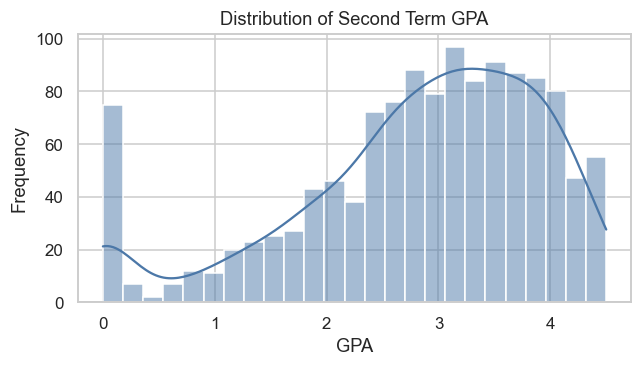

In [10]:
# explorer = DataExplorer(structured_data_file)
# explorer.run_full_analysis()

# Analyze target variable distribution
plt.figure(figsize=(6,3.5))

sns.histplot(y, bins=25, kde=True, color="#4c78a8")
plt.title("Distribution of Second Term GPA")
plt.xlabel("GPA")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [11]:
# number of students have value 0 in second_term_gpa column
num_zero_gpa = (y == 0).sum()
print(f"Number of students with second term GPA of 0: {num_zero_gpa}")

Number of students with second term GPA of 0: 72


### Train-Test Protocol

In [12]:
# test-train split with stratification and train-only feature fitting
X_train_raw, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw,
    y_train,
    test_size=0.125,  # 10% of total
    random_state=42,
)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

X_train: (893, 12), X_val: (128, 12), X_test: (256, 12)


In [13]:
# check the final training dataset
display(X_train.head())

,first_term_gpa,first_language,funding,fast_track,coop,residency,gender,previous_education,age_group,high_school_average_mark,math_score,english_grade
78,3.521739,3,4.0,1.0,2.0,2.0,1.0,1,3,?,?,7
353,2.25,1,2.0,2.0,2.0,1.0,2.0,2,2,83,?,7
1354,3.4,3,4.0,1.0,2.0,2.0,1.0,2,4,?,?,8
510,4.214286,1,2.0,2.0,1.0,1.0,2.0,2,4,73,49,9
338,2.547619,1,2.0,2.0,1.0,1.0,2.0,1,2,78,27,9


### Data Cleaning

In [14]:
# Data cleaning
cleaner = DataCleaner(numeric_imputer="bayesian")

X_train = cleaner.fit_transform(X_train)
X_val = cleaner.transform(X_val)
X_test = cleaner.transform(X_test)

# Target standardization
scaler = MinMaxScaler()
y_train = scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val = scaler.transform(y_val.values.reshape(-1, 1)).flatten()
y_test = scaler.transform(y_test.values.reshape(-1, 1)).flatten()


In [15]:
import joblib

# save the preprocessing pipeline (DataCleaner object) to a file for later use in inference
joblib.dump(cleaner, project_path / "second_term_gpa_regression" / "models" / "best_model" / "preprocessing_pipeline.pkl")
joblib.dump(scaler, project_path / "second_term_gpa_regression" / "models" / "best_model" / "target_scaler.pkl")

# check the training after cleaning
display(X_train.head())

,first_term_gpa,fast_track,coop,residency,age_group,high_school_average_mark,math_score,english_grade,high_school_average_mark_missing,english_grade_missing,...,gender_1,gender_2,previous_education_0,previous_education_1,previous_education_2,previous_education_3,gpa_category_0,gpa_category_1,gpa_category_2,gpa_category_3
78,0.485630,1,0,0,3.0,0.335862,0.248844,7.0,1,0,...,True,False,False,True,False,False,False,False,False,True
353,-0.762264,0,0,1,2.0,0.270222,0.122663,7.0,0,0,...,False,True,False,False,True,False,False,False,True,False
1354,0.366174,1,0,0,4.0,0.253814,0.187655,8.0,1,0,...,True,False,False,False,True,False,False,False,False,True
510,1.165193,0,1,1,4.0,-0.751768,1.665857,9.0,0,0,...,False,True,False,False,True,False,False,False,False,True
338,-0.470226,0,1,1,2.0,-0.240773,-0.703704,9.0,0,0,...,False,True,False,True,False,False,False,False,True,False


### Experiment 1: Baseline Model - ANN

In [16]:
baseline_layers = [
    {'units': 128, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.2},
    {'units': 64, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.2},
    {'units': 32, 'activation': 'relu', 'batch_norm': False, 'dropout': 0.0},
]

baseline_model = build_dense_model(X_train.shape[1], baseline_layers)
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           4,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,129 (63.00 KB)

 Trainable params: 15,745 (61.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [17]:
baseline_model = compile_regression_model(baseline_model, optimizer_name='adam', learning_rate=0.001)

baseline_es, baseline_mc = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'regression_model.keras',
)

history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[baseline_es, baseline_mc],
    verbose=1,
)

Epoch 1/200
20/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5270 - mae: 0.5597 - r2: -7.1709 - rmse: 0.7220
Epoch 1: val_loss improved from None to 0.08777, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\regression_model.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\regression_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.3741 - mae: 0.4668 - r2: -4.6795 - rmse: 0.6116 - val_loss: 0.0878 - val_mae: 0.2490 - val_r2: -0.5039 - val_rmse: 0.2963
Epoch 2/200
20/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2245 - mae: 0.3685 - r2: -2.3799 - rmse: 0.4735
Epoch 2: val_loss did not improve from 0.08777
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1903 - mae: 0.3367 - r2: -1.8893 - rmse: 0.4363 - val_loss: 0.1375 - val_mae: 0.3343 - val_r2: -1.3565 - val_rmse: 0.3708

### Baseline Evaluation

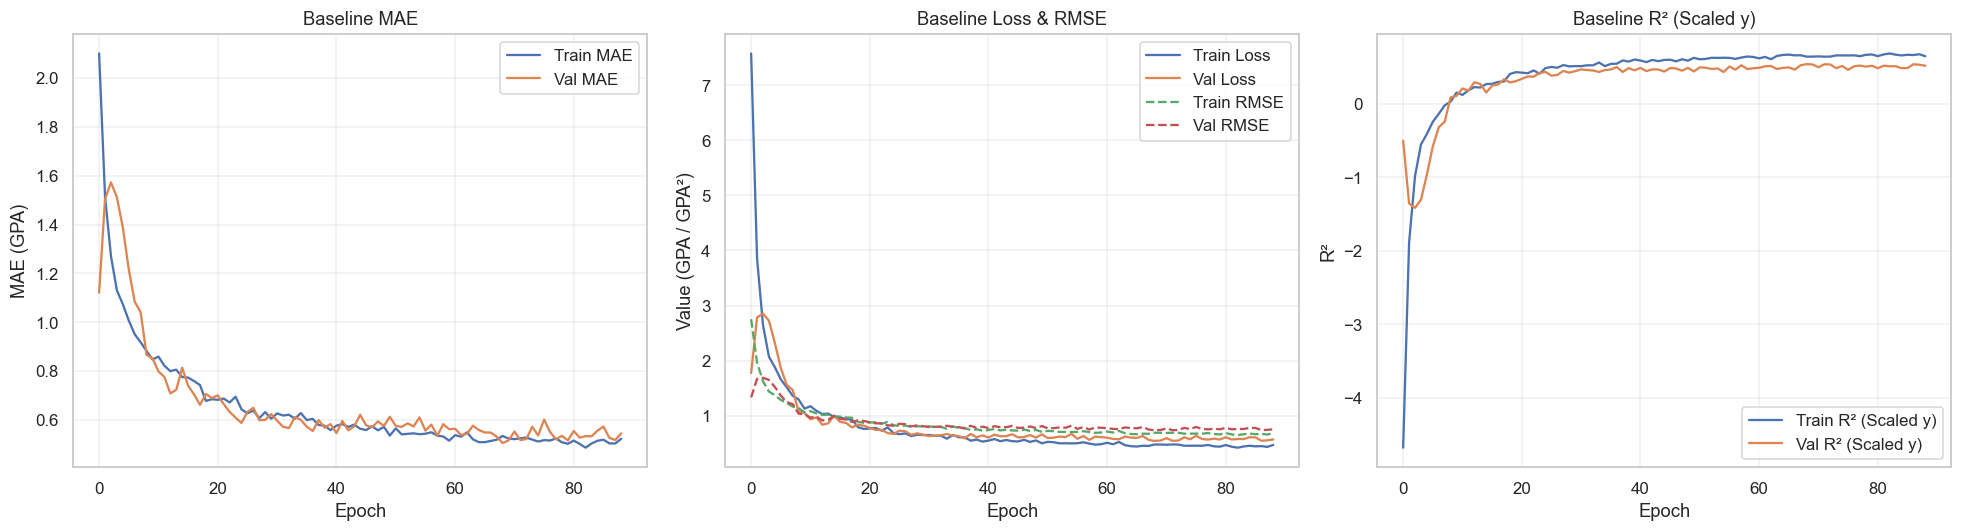


Best Epoch: 69
----------------------------------------
MAE (GPA)   -> Train: 0.5341 | Val: 0.5051
RMSE (GPA)  -> Train: 0.6921 | Val: 0.7380
Loss (GPA²) -> Train: 0.4790 | Val: 0.5446
R² (Scaled y) -> Train: 0.6409 | Val: 0.5392


In [18]:
plot_regression_history(history_baseline, title_prefix='Baseline')

In [19]:
baseline_val_metrics, baseline_val_df = evaluate_model_original_scale(
    baseline_model, X_val, y_val, scaler, split_name='Baseline Validation'
)
baseline_test_metrics, baseline_test_df = evaluate_model_original_scale(
    baseline_model, X_test, y_test, scaler, split_name='Baseline Test'
)

baseline_summary_df = pd.DataFrame([baseline_val_metrics, baseline_test_metrics]).set_index('split')
display(format_metrics_display(baseline_summary_df))
display(baseline_test_df.head(15))

Baseline Validation RMSE: 0.7380
Baseline Validation MSE:  0.5446
Baseline Validation MAE:              0.5051
Baseline Validation R² (Original GPA): 0.5392
Baseline Validation R² (Scaled y):     0.5392
Baseline Test RMSE: 0.6480
Baseline Test MSE:  0.4199
Baseline Test MAE:              0.4916
Baseline Test R² (Original GPA): 0.6194
Baseline Test R² (Scaled y):     0.6194


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Baseline Validation,0.737959,0.544583,0.505073,0.539191,0.539191
Baseline Test,0.647986,0.419886,0.491585,0.619405,0.619405


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,3.000000,0.344717,2.655283,2.655283,7.050526
1,0.000000,2.213483,-2.213483,2.213483,4.899506
2,2.978261,0.851743,2.126518,2.126518,4.522077
3,3.095238,1.148805,1.946433,1.946433,3.788603
4,1.857143,0.038106,1.819037,1.819037,3.308897
5,3.222222,1.403959,1.818263,1.818263,3.306079
6,2.000000,0.327617,1.672383,1.672383,2.796865
7,3.375000,1.744459,1.630541,1.630541,2.658663
8,2.826087,1.225342,1.600745,1.600745,2.562386
9,0.000000,1.371959,-1.371959,1.371959,1.882270


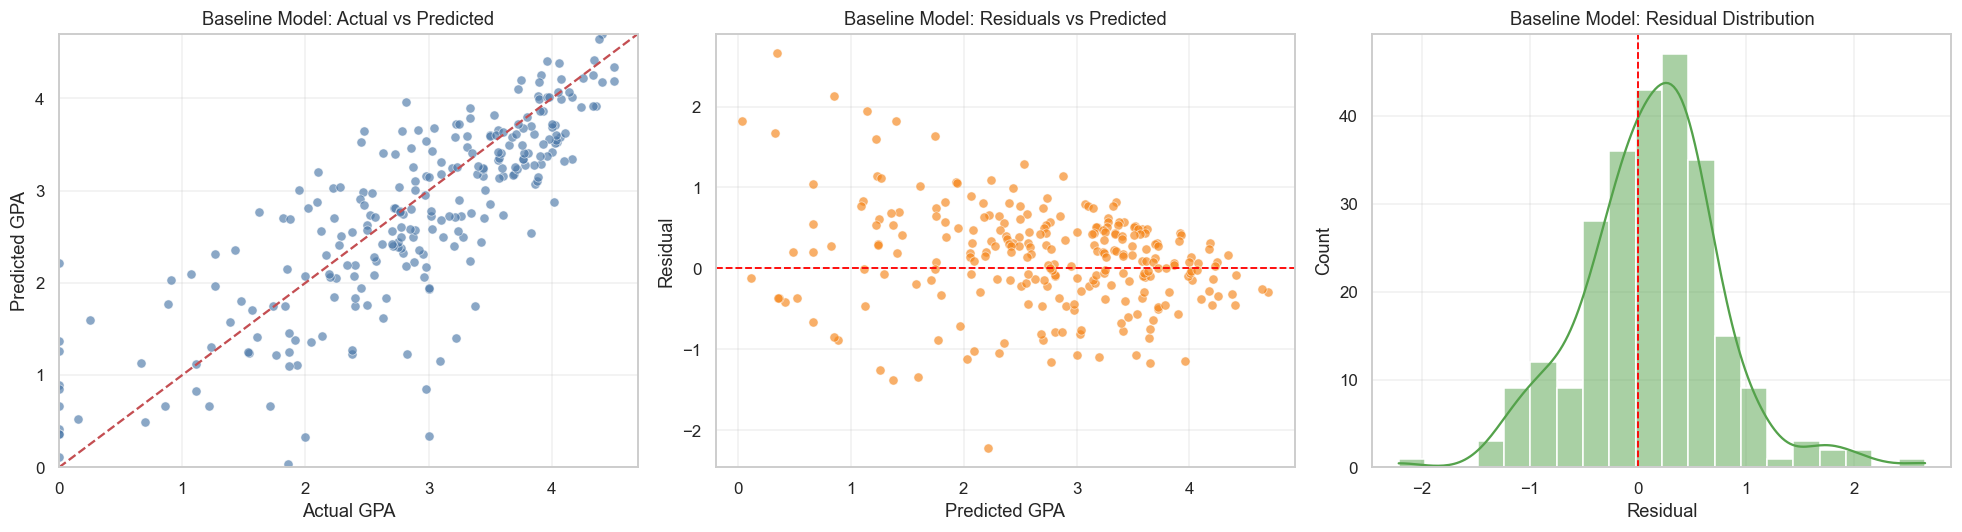

In [20]:
plot_prediction_diagnostics(baseline_test_df, title_prefix='Baseline Model')

### Experiment 2: Baseline Model - RNN with Bayesian Imputation

In [21]:
X_train_rnn = np.array(X_train).reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_rnn = np.array(X_val).reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_rnn = np.array(X_test).reshape(X_test.shape[0], X_test.shape[1], 1)

X_train_rnn = np.asarray(X_train_rnn).astype(np.float32)
X_val_rnn = np.asarray(X_val_rnn).astype(np.float32)
X_test_rnn = np.asarray(X_test_rnn).astype(np.float32)

y_train_rnn = np.asarray(y_train).astype(np.float32)
y_val_rnn = np.asarray(y_val).astype(np.float32)
y_test_rnn = np.asarray(y_test).astype(np.float32)

print(X_train_rnn.shape)   #

(893, 38, 1)


In [22]:
#build rnn model for based model above
from tensorflow.keras.layers import SimpleRNN, Input

baseline_rnn = Sequential([
    Input(shape=(X_train_rnn.shape[1], X_train_rnn.shape[2])),
    SimpleRNN(128, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),

    SimpleRNN(64, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),

    SimpleRNN(32, activation='tanh'),
    Dense(1)
])

baseline_rnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 38, 128)             │          16,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 38, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 38, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 38, 64)              │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 38, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 38, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_2 (SimpleRNN)             │ (None, 32)                  │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,897 (128.50 KB)

 Trainable params: 32,513 (127.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [23]:
baseline_rnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', RMSEMetric(name='rmse'), R2Metric(name='r2')]
)

es_rnn, mc_rnn = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'rnn_ baseline_model.keras'
)   

In [24]:
history_rnn = baseline_rnn.fit(
    X_train_rnn, y_train_rnn,
    validation_data=(X_val_rnn, y_val_rnn),
    epochs=100,
    batch_size=32,
    callbacks = [es_rnn, mc_rnn],
    verbose=1
)

Epoch 1/100
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.7307 - mae: 0.6472 - r2: -10.3181 - rmse: 0.8423
Epoch 1: val_loss improved from None to 0.10401, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\rnn_ baseline_model.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\rnn_ baseline_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 0.4669 - mae: 0.5242 - r2: -6.0888 - rmse: 0.6833 - val_loss: 0.1040 - val_mae: 0.2729 - val_r2: -0.7823 - val_rmse: 0.3225
Epoch 2/100
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1906 - mae: 0.3408 - r2: -1.8434 - rmse: 0.4360
Epoch 2: val_loss improved from 0.10401 to 0.07952, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\rnn_ baseline_mod

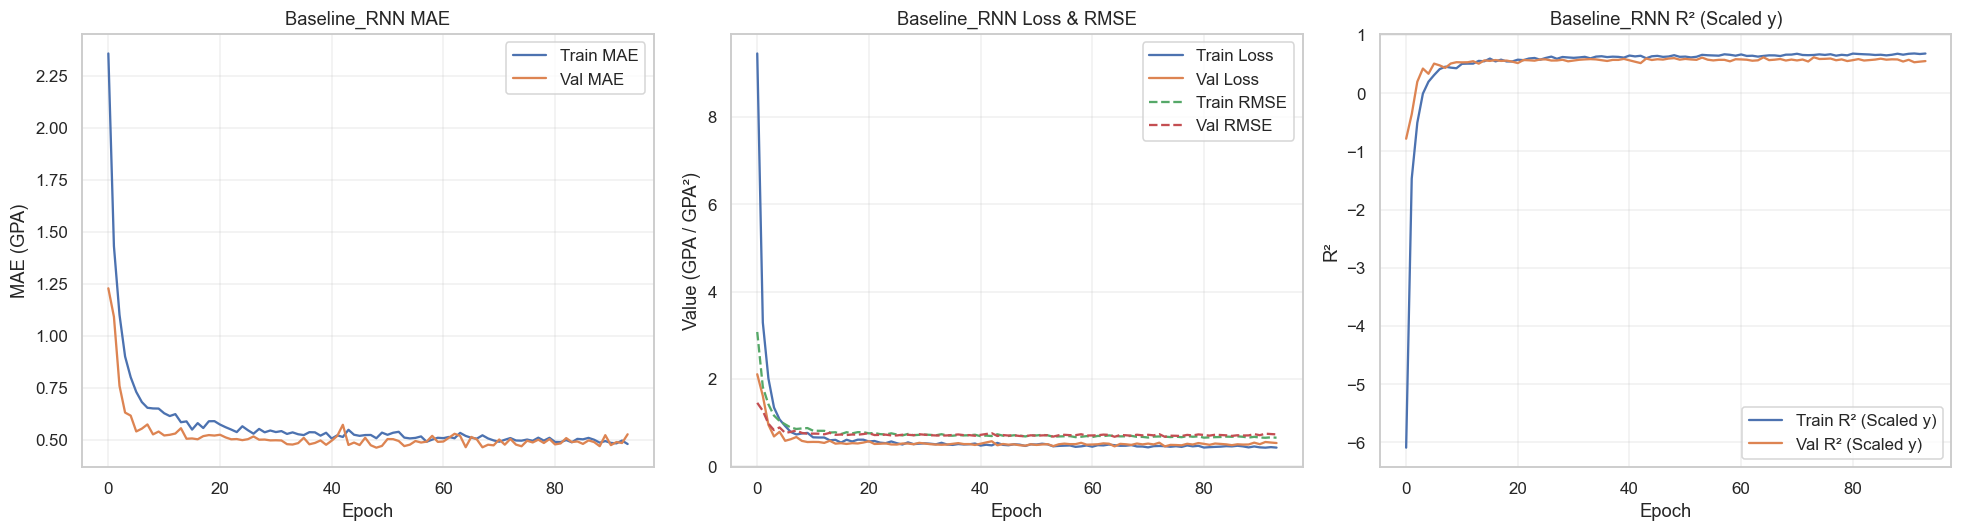


Best Epoch: 74
----------------------------------------
MAE (GPA)   -> Train: 0.4955 | Val: 0.4757
RMSE (GPA)  -> Train: 0.6771 | Val: 0.6731
Loss (GPA²) -> Train: 0.4585 | Val: 0.4530
R² (Scaled y) -> Train: 0.6563 | Val: 0.6167


In [25]:
plot_regression_history(history_rnn, title_prefix='Baseline_RNN')

In [26]:
baseline_rnn_val_metrics, baseline_rnn_val_df = evaluate_model_original_scale(
    baseline_rnn, X_val_rnn, y_val_rnn, scaler, split_name='Baseline RNN Validation'
)
baseline_rnn_test_metrics, baseline_rnn_test_df = evaluate_model_original_scale(
    baseline_rnn, X_test_rnn, y_test_rnn, scaler, split_name='Baseline RNN Test'
)

baseline_rnn_summary_df = pd.DataFrame([baseline_rnn_val_metrics, baseline_rnn_test_metrics]).set_index('split')
display(format_metrics_display(baseline_rnn_summary_df))
display(baseline_rnn_test_df.head(15))

Baseline RNN Validation RMSE: 0.6731
Baseline RNN Validation MSE:  0.4530
Baseline RNN Validation MAE:              0.4757
Baseline RNN Validation R² (Original GPA): 0.6167
Baseline RNN Validation R² (Scaled y):     0.6167
Baseline RNN Test RMSE: 0.6224
Baseline RNN Test MSE:  0.3873
Baseline RNN Test MAE:              0.4681
Baseline RNN Test R² (Original GPA): 0.6489
Baseline RNN Test R² (Scaled y):     0.6489


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Baseline RNN Validation,0.673066,0.453018,0.475729,0.616671,0.616671
Baseline RNN Test,0.622359,0.387331,0.468099,0.648914,0.648914


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,0.000000,2.062516,-2.062516,2.062516,4.253973
1,0.000000,2.016136,-2.016136,2.016136,4.064806
2,3.000000,1.226777,1.773223,1.773223,3.144321
3,0.000000,1.748521,-1.748521,1.748521,3.057326
4,0.000000,1.675888,-1.675888,1.675888,2.808600
5,0.000000,1.585168,-1.585168,1.585168,2.512757
6,3.375000,1.796362,1.578638,1.578638,2.492099
7,0.000000,1.560029,-1.560029,1.560029,2.433689
8,1.269231,2.803606,-1.534375,1.534375,2.354306
9,0.250000,1.769538,-1.519538,1.519538,2.308995


### Experiment 3: Baseline Model - LSTM with Bayesian Imputation

In [27]:
from tensorflow.keras.layers import  LSTM

# make sure dtype is numeric
X_train_lstm = np.asarray(X_train_rnn).astype(np.float32)
X_val_lstm = np.asarray(X_val_rnn).astype(np.float32)
X_test_lstm = np.asarray(X_test_rnn).astype(np.float32)

y_train_lstm = np.asarray(y_train).astype(np.float32)
y_val_lstm = np.asarray(y_val).astype(np.float32)
y_test_lstm = np.asarray(y_test).astype(np.float32)

In [28]:
baseline_lstm = Sequential([
    Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),

    LSTM(128, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),

    LSTM(64, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),

    LSTM(32, activation='tanh'),
    Dense(1)
])

baseline_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 38, 128)             │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 38, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 38, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 38, 64)              │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 38, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 38, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 129,185 (504.63 KB)

 Trainable params: 128,801 (503.13 KB)

 Non-trainable params: 384 (1.50 KB)

In [29]:
baseline_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', RMSEMetric(name='rmse'), R2Metric(name='r2')]
)

es_lstm, mc_lstm = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'lstm_baseline_model.keras'
)

history_lstm = baseline_lstm.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=100,
    batch_size=32,
    callbacks=[es_lstm, mc_lstm],
    verbose=1
)

Epoch 1/100


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0865 - mae: 0.2230 - r2: -0.3776 - rmse: 0.2879
Epoch 1: val_loss improved from None to 0.44876, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\lstm_baseline_model.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\lstm_baseline_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 140ms/step - loss: 0.0540 - mae: 0.1718 - r2: 0.1807 - rmse: 0.2323 - val_loss: 0.4488 - val_mae: 0.6251 - val_r2: -6.6894 - val_rmse: 0.6699
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0308 - mae: 0.1351 - r2: 0.5428 - rmse: 0.1753
Epoch 2: val_loss did not improve from 0.44876
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0325 - mae: 0.1384 - r2: 0.5063 - rmse: 0.1803 - val_loss: 0.4683 - val_mae: 0.6374 - val_r2: -7.0249 - val_rmse: 0.6844
Epo

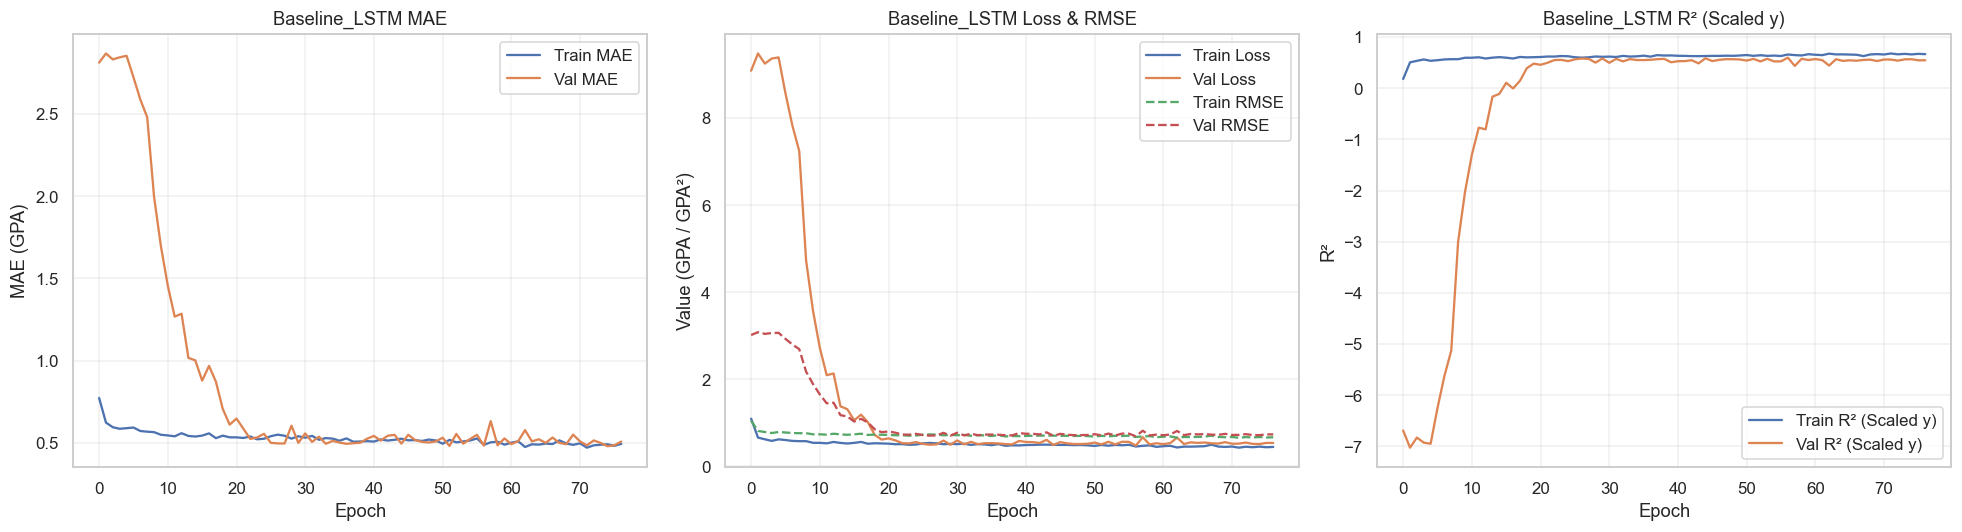


Best Epoch: 57
----------------------------------------
MAE (GPA)   -> Train: 0.4881 | Val: 0.4833
RMSE (GPA)  -> Train: 0.6733 | Val: 0.6889
Loss (GPA²) -> Train: 0.4533 | Val: 0.4746
R² (Scaled y) -> Train: 0.6602 | Val: 0.5984


In [30]:
plot_regression_history(history_lstm, title_prefix='Baseline_LSTM')

In [31]:
baseline_lstm_val_metrics, baseline_lstm_val_df = evaluate_model_original_scale(
    baseline_lstm, X_val_lstm, y_val_lstm, scaler, split_name='Baseline LSTM Validation'
)
baseline_lstm_test_metrics, baseline_lstm_test_df = evaluate_model_original_scale(
    baseline_lstm, X_test_lstm, y_test_lstm, scaler, split_name='Baseline LSTM Test'
)

baseline_lstm_summary_df = pd.DataFrame([baseline_lstm_val_metrics, baseline_lstm_test_metrics]).set_index('split')
display(format_metrics_display(baseline_lstm_summary_df))
display(baseline_lstm_test_df.head(15))

Baseline LSTM Validation RMSE: 0.6889
Baseline LSTM Validation MSE:  0.4746
Baseline LSTM Validation MAE:              0.4833
Baseline LSTM Validation R² (Original GPA): 0.5984
Baseline LSTM Validation R² (Scaled y):     0.5984
Baseline LSTM Test RMSE: 0.5928
Baseline LSTM Test MSE:  0.3514
Baseline LSTM Test MAE:              0.4467
Baseline LSTM Test R² (Original GPA): 0.6815
Baseline LSTM Test R² (Scaled y):     0.6815


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Baseline LSTM Validation,0.688912,0.474599,0.483280,0.598409,0.598409
Baseline LSTM Test,0.592807,0.351421,0.446745,0.681464,0.681464


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,1.269231,3.219152,-1.949921,1.949921,3.802194
1,0.250000,2.150290,-1.900290,1.900290,3.611102
2,0.000000,1.706994,-1.706994,1.706994,2.913828
3,0.000000,1.695022,-1.695022,1.695022,2.873099
4,0.000000,1.650932,-1.650932,1.650932,2.725577
5,1.619048,3.218040,-1.598992,1.598992,2.556777
6,2.500000,4.003714,-1.503714,1.503714,2.261155
7,3.000000,1.523853,1.476147,1.476147,2.179010
8,0.000000,1.449514,-1.449514,1.449514,2.101092
9,0.000000,1.383217,-1.383217,1.383217,1.913290


### Experiment 4: Keras Tuner - Automatic Hyperband Search for LSTM Based on Baseline Results

In [34]:
def build_tuner_model(hp):
    num_layers = hp.Int('num_layers', 1, 5)
    layer_specs = [{'units': hp.Choice(f'neurons_{i}', [64, 128, 256, 512, 1024]),
                    'activation': hp.Choice(f'act_{i}', ['relu', 'tanh', 'elu']),
                    'dropout': hp.Float(f'dropout_{i}', 0.1, 0.5, step=0.1)} for i in range(num_layers)]

    tuner_model = Sequential([Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
                              LSTM(layer_specs[0]['units'], activation=layer_specs[0]['activation'], return_sequences=(num_layers > 1)),
                              BatchNormalization(),
                              Dropout(layer_specs[0]['dropout'])])

    for i in range(1, num_layers):
        tuner_model.add(LSTM(layer_specs[i]['units'], activation=layer_specs[i]['activation'], return_sequences=(i < num_layers - 1)))
        tuner_model.add(BatchNormalization())
        tuner_model.add(Dropout(layer_specs[i]['dropout']))

    tuner_model.add(Dense(1))
    return compile_regression_model(
        tuner_model,
        optimizer_name=hp.Choice('optimizer', ['adam', 'sgd', 'rmsprop']),
        learning_rate=hp.Choice('learning_rate', [0.0001, 0.0005, 0.001, 0.002, 0.003, 0.004, 0.005, 0.01])
    )


def show_best_hyperparameters(hyperparameters):
    rows = [{'hyperparameter': k, 'value': v} for k, v in hyperparameters.values.items()]
    display(pd.DataFrame(rows))

In [ ]:
tuner_dir = project_path / 'second_term_gpa_regression' / 'tuner' / 'student_tuner'
if tuner_dir.exists():
    shutil.rmtree(tuner_dir, ignore_errors=True)

print_header('KERAS TUNER SEARCH')

hyperband_tuner = Hyperband(
    hypermodel=build_tuner_model,
    objective='val_loss',
    max_epochs=40,
    factor=3,
    directory=tuner_dir,
    project_name='student_tuner',
    seed=42,
    overwrite=True,
)

search_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=0,
    mode='min',
)

search_start = time.time()
hyperband_tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    callbacks=[search_stop],
    verbose=1,
)
search_time = time.time() - search_start

print(f'Search completed in {search_time / 60:.1f} minutes')
hyperband_tuner.results_summary(num_trials=10)

best_hps = hyperband_tuner.get_best_hyperparameters(1)[0]
print_header('BEST HYPERPARAMETERS')
show_best_hyperparameters(best_hps)

Trial 68 Complete [00h 02m 01s]
val_loss: 0.02541392669081688

Best val_loss So Far: 0.02541392669081688
Total elapsed time: 02h 30m 34s

Search: Running Trial #69

Value             |Best Value So Far |Hyperparameter
5                 |1                 |num_layers
1024              |128               |neurons_0
relu              |elu               |act_0
0.3               |0.2               |dropout_0
rmsprop           |adam              |optimizer
0.001             |0.01              |learning_rate
64                |512               |neurons_1
elu               |relu              |act_1
0.2               |0.1               |dropout_1
1024              |64                |neurons_2
tanh              |elu               |act_2
0.2               |0.2               |dropout_2
512               |64                |neurons_3
relu              |relu              |act_3
0.3               |0.3               |dropout_3
512               |64                |neurons_4
tanh              |relu  

### Hyperband Results

In [ ]:
all_trials = list(hyperband_tuner.oracle.trials.values())
target_scale = get_target_scale(scaler)
mse_scale = target_scale ** 2

tuning_results_df = pd.DataFrame([
    {
        'Loss (GPA²)': (t.metrics.metrics['loss'].get_best_value() * mse_scale) if 'loss' in t.metrics.metrics else None,
        'Val_Loss (GPA²)': (t.metrics.metrics['val_loss'].get_best_value() * mse_scale) if 'val_loss' in t.metrics.metrics else None,
        'MAE (GPA)': (t.metrics.metrics['mae'].get_best_value() * target_scale) if 'mae' in t.metrics.metrics else None,
        'Val_MAE (GPA)': (t.metrics.metrics['val_mae'].get_best_value() * target_scale) if 'val_mae' in t.metrics.metrics else None,
        'RMSE (GPA)': (t.metrics.metrics['rmse'].get_best_value() * target_scale) if 'rmse' in t.metrics.metrics else None,
        'Val_RMSE (GPA)': (t.metrics.metrics['val_rmse'].get_best_value() * target_scale) if 'val_rmse' in t.metrics.metrics else None,
        'R2 (Scaled y)': t.metrics.metrics['r2'].get_best_value() if 'r2' in t.metrics.metrics else None,
        'Val_R2 (Scaled y)': t.metrics.metrics['val_r2'].get_best_value() if 'val_r2' in t.metrics.metrics else None,
        **t.hyperparameters.values,
    }
    for t in all_trials
]).sort_values('Val_Loss (GPA²)', ascending=True).reset_index(drop=True)

tuning_results_df.insert(0, 'ID', range(1, len(tuning_results_df) + 1))
tuning_results_df.to_csv(
    project_path / 'second_term_gpa_regression' / 'trial_results' / 'keras_tuner_results_regression_bayesian.csv',
    index=False,
)

print('TOP 20 BEST TRIALS (loss/MAE/RMSE in original GPA scale, R² in scaled y)')
print(tuning_results_df.head(20).to_string(index=False))

NameError: name 'hyperband_tuner' is not defined

In [ ]:
best_model = hyperband_tuner.hypermodel.build(best_hps)
best_model.summary()

best_es, best_mc = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'best_regression_model_bayesian.keras',
)

history_best = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    callbacks=[best_es, best_mc],
    verbose=1,
)

print('Training completed.')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 256)                 │           9,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1024)                │         263,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 1024)                │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         131,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 418,561 (1.60 MB)

 Trainable params: 415,617 (1.59 MB)

 Non-trainable params: 2,944 (11.50 KB)

Epoch 1/200
25/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.3855 - mae: 0.8908 - r2: -22.0612 - rmse: 1.1519
Epoch 1: val_loss improved from None to 0.05101, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\best_regression_model_bayesian.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\best_regression_model_bayesian.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.6714 - mae: 0.5806 - r2: -9.1934 - rmse: 0.8194 - val_loss: 0.0510 - val_mae: 0.1830 - val_r2: 0.1260 - val_rmse: 0.2258
Epoch 2/200
26/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1131 - mae: 0.2527 - r2: -0.6280 - rmse: 0.3346
Epoch 2: val_loss improved from 0.05101 to 0.04089, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\mode

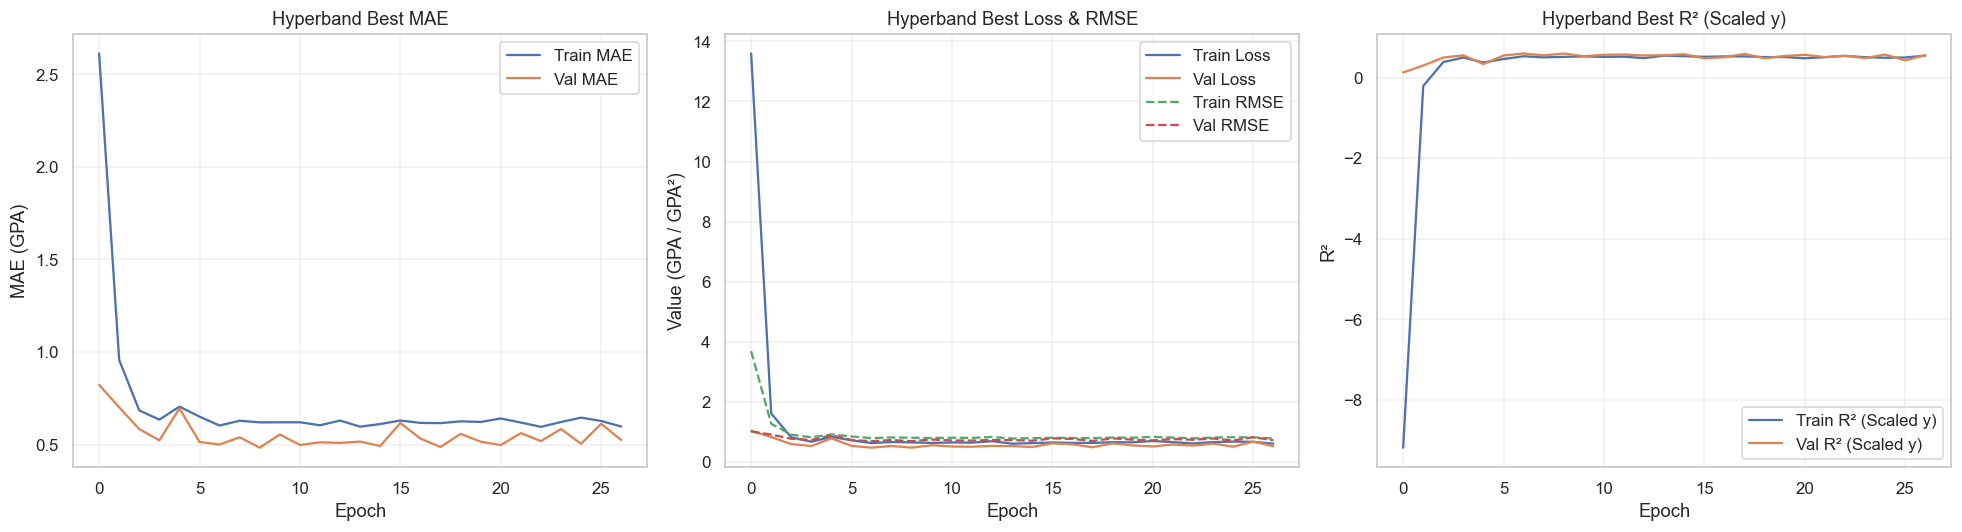


Best Epoch: 7
----------------------------------------
MAE (GPA)   -> Train: 0.6033 | Val: 0.5009
RMSE (GPA)  -> Train: 0.7925 | Val: 0.6889
Loss (GPA²) -> Train: 0.6280 | Val: 0.4745
R² (Scaled y) -> Train: 0.5292 | Val: 0.5985


In [ ]:
plot_regression_history(history_best, title_prefix='Hyperband Best')

In [ ]:
best_val_metrics, best_val_df = evaluate_model_original_scale(
    best_model, X_val, y_val, scaler, split_name='Hyperband Validation'
)
best_test_metrics, best_test_df = evaluate_model_original_scale(
    best_model, X_test, y_test, scaler, split_name='Hyperband Test'
)

best_summary_df = pd.DataFrame([best_val_metrics, best_test_metrics]).set_index('split')
display(format_metrics_display(best_summary_df))
display(best_test_df.head(15))

NameError: name 'best_model' is not defined

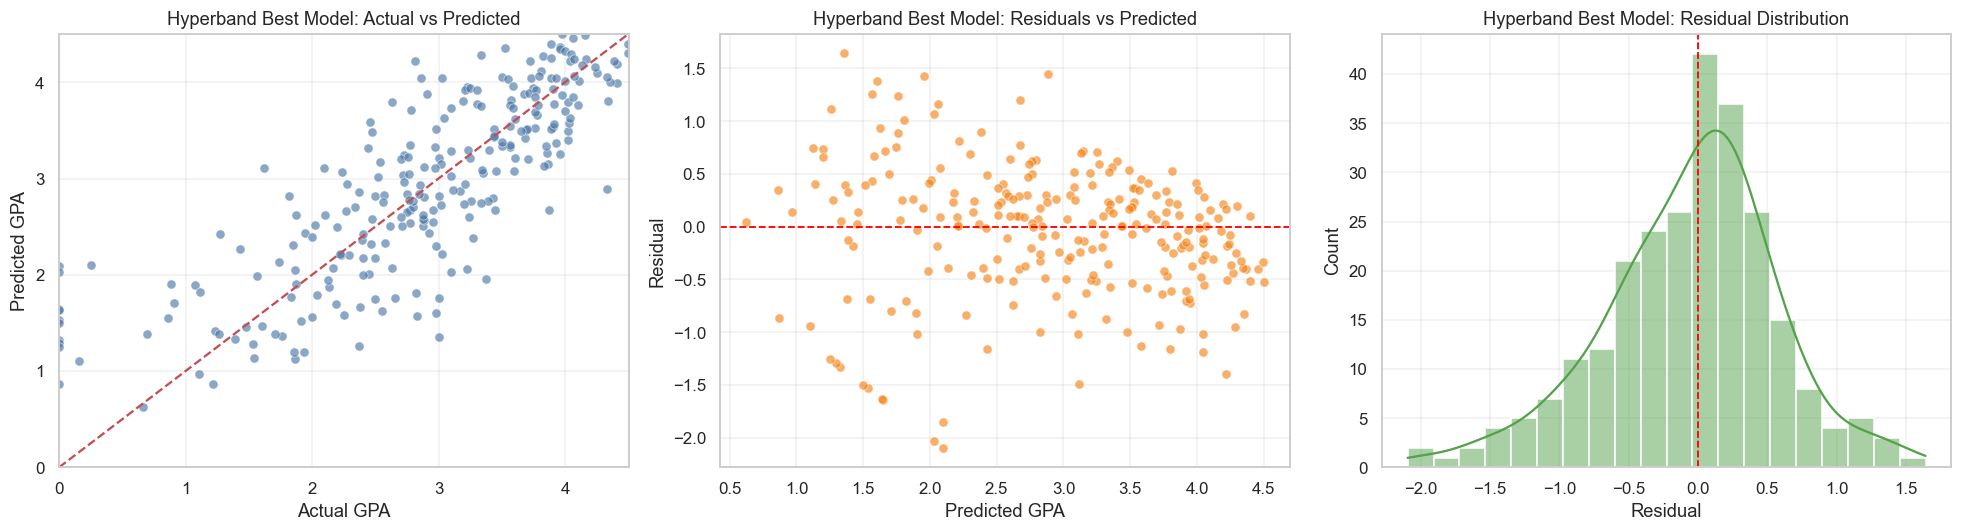

In [ ]:
plot_prediction_diagnostics(best_test_df, title_prefix='Hyperband Best Model')

### Experiment 3: Custom Model based on Hyperband Findings

In [ ]:
custom_layers = [
    {'units': 516, 'activation': 'tanh', 'batch_norm': True, 'dropout': 0.1},
    {'units': 128, 'activation': 'elu', 'batch_norm': True, 'dropout': 0.2},
]

custom_model = build_dense_model(X_train.shape[1], custom_layers)
custom_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                     │ (None, 516)                 │          20,124 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_27               │ (None, 516)                 │           2,064 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_27 (Dropout)                 │ (None, 516)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_41 (Dense)                     │ (None, 128)                 │          66,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_28               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_28 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 89,005 (347.68 KB)

 Trainable params: 87,717 (342.64 KB)

 Non-trainable params: 1,288 (5.03 KB)

In [ ]:
custom_model = compile_regression_model(custom_model, optimizer_name='sgd', learning_rate=0.0009)

custom_es, custom_mc = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'custom_model_bayesian.keras',
)

history_custom = custom_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    callbacks=[custom_es, custom_mc],
    verbose=1,
)

Epoch 1/200
26/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.5614 - mae: 0.9666 - r2: -22.0786 - rmse: 1.2478
Epoch 1: val_loss improved from None to 0.20937, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\custom_model_bayesian.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\custom_model_bayesian.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 1.2485 - mae: 0.8666 - r2: -17.9533 - rmse: 1.1173 - val_loss: 0.2094 - val_mae: 0.3907 - val_r2: -2.5875 - val_rmse: 0.4576
Epoch 2/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4625 - mae: 0.5285 - r2: -5.8929 - rmse: 0.6789
Epoch 2: val_loss improved from 0.20937 to 0.06343, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\custom_model_ba

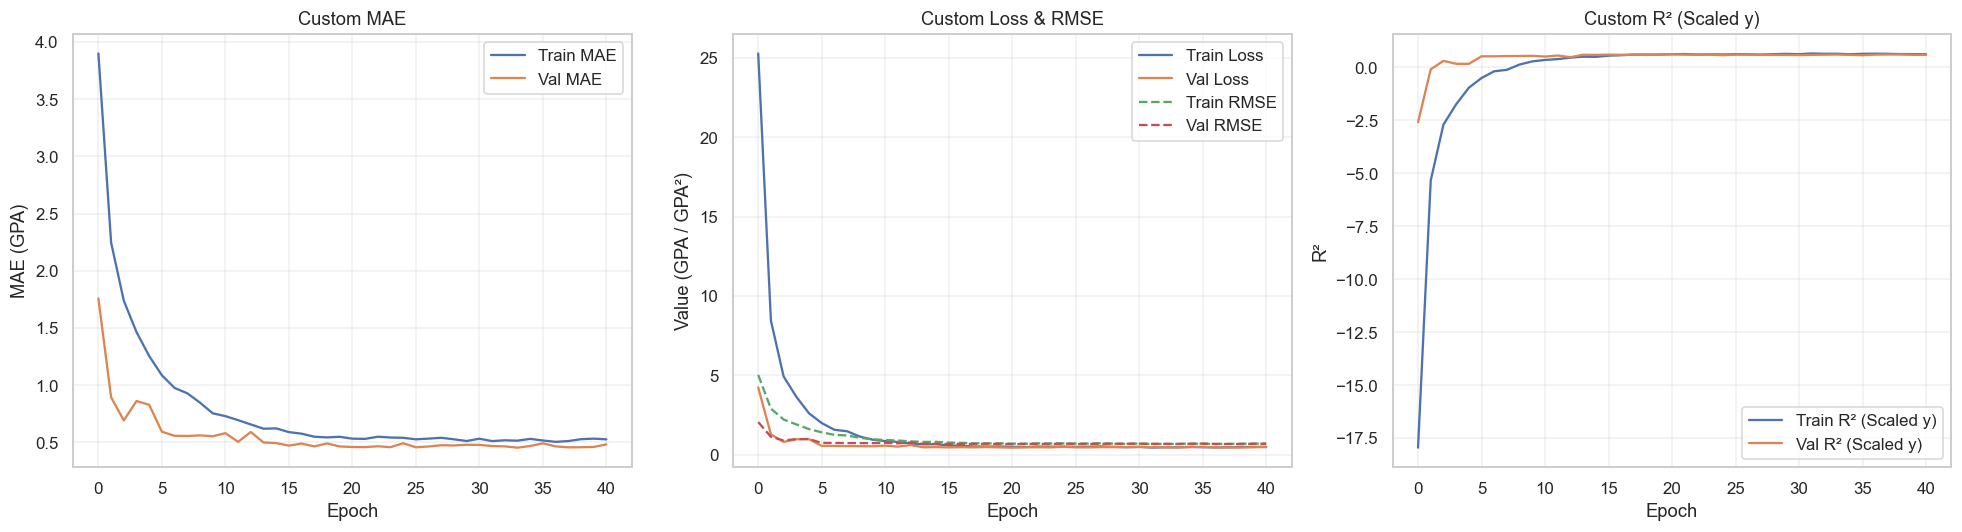


Best Epoch: 21
----------------------------------------
MAE (GPA)   -> Train: 0.5326 | Val: 0.4598
RMSE (GPA)  -> Train: 0.7063 | Val: 0.6695
Loss (GPA²) -> Train: 0.4988 | Val: 0.4482
R² (Scaled y) -> Train: 0.6261 | Val: 0.6208


In [ ]:
plot_regression_history(history_custom, title_prefix='Custom')

In [ ]:
custom_val_metrics, custom_val_df = evaluate_model_original_scale(
    custom_model, X_val, y_val, scaler, split_name='Custom Validation'
)
custom_test_metrics, custom_test_df = evaluate_model_original_scale(
    custom_model, X_test, y_test, scaler, split_name='Custom Test'
)

custom_summary_df = pd.DataFrame([custom_val_metrics, custom_test_metrics]).set_index('split')
display(format_metrics_display(custom_summary_df))
display(custom_test_df.head(15))

Custom Validation RMSE: 0.6695
Custom Validation MSE:  0.4482
Custom Validation MAE:              0.4598
Custom Validation R² (Original GPA): 0.6208
Custom Validation R² (Scaled y):     0.6208
Custom Test RMSE: 0.5810
Custom Test MSE:  0.3376
Custom Test MAE:              0.4504
Custom Test R² (Original GPA): 0.6940
Custom Test R² (Scaled y):     0.6940


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Custom Validation,0.669459,0.448176,0.459802,0.620768,0.620768
Custom Test,0.581006,0.337568,0.450419,0.694020,0.694020


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,3.000000,0.925911,2.074089,2.074089,4.301846
1,0.000000,1.768952,-1.768952,1.768952,3.129191
2,0.000000,1.743660,-1.743660,1.743660,3.040351
3,0.250000,1.945948,-1.695948,1.695948,2.876240
4,0.000000,1.692855,-1.692855,1.692855,2.865759
5,2.978261,1.395991,1.582270,1.582270,2.503577
6,3.375000,1.975547,1.399453,1.399453,1.958469
7,1.269231,2.661661,-1.392430,1.392430,1.938862
8,0.000000,1.379818,-1.379818,1.379818,1.903899
9,3.095238,1.812370,1.282868,1.282868,1.645750


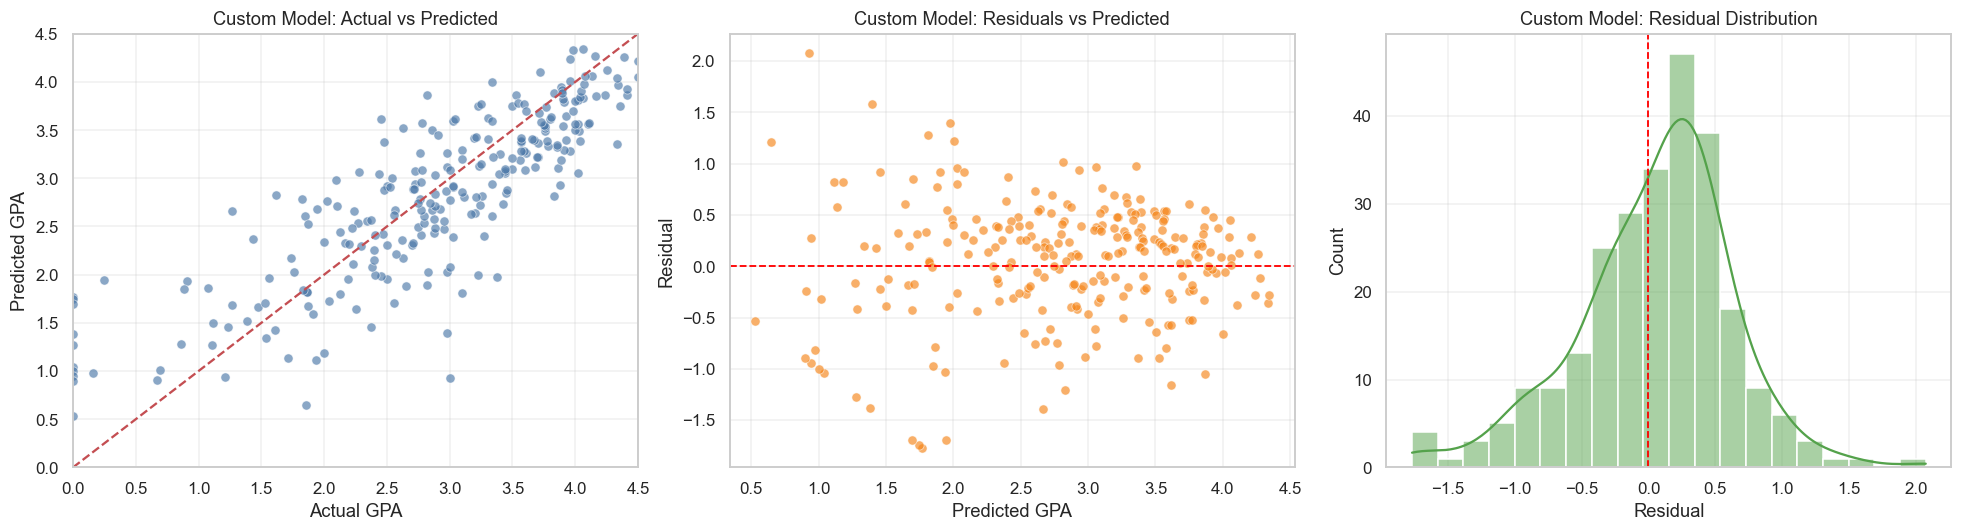

In [ ]:
plot_prediction_diagnostics(custom_test_df, title_prefix='Custom Model')

### Experiment 4: Local Search around the Custom Architecture

In [ ]:
# trying to find the local minimum around the custom model configuration by varying learning rate and batch size

base_layers = [
    {'units': 516, 'activation': 'tanh', 'batch_norm': True, 'dropout': 0.10},
    {'units': 128, 'activation': 'elu', 'batch_norm': True, 'dropout': 0.20},
]

local_search_configs = [
    {'trial_name': 'SGD-lr0.00085-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00085, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00088-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00088, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00090-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00092-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00092, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00095-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00095, 'batch_size': 64},

    {'trial_name': 'SGD-lr0.00090-bs32', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 32},
    {'trial_name': 'SGD-lr0.00090-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00090-bs96', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 96},
    {'trial_name': 'SGD-lr0.00090-bs128', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 128},
]

local_search_results = []
local_search_models = {}
local_search_histories = {}
best_local_model = None
best_local_history = None
best_local_metrics = None
best_local_config = None
best_local_sort_key = None

for trial_idx, config in enumerate(local_search_configs, start=1):
    print_header(config['trial_name'])

    trial_model = build_dense_model(X_train.shape[1], config['layers'])
    trial_model = compile_regression_model(trial_model, optimizer_name=config['optimizer'], learning_rate=config['learning_rate'])

    trial_es = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1,
        mode='min',
    )

    trial_history = trial_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=200,
        batch_size=config['batch_size'],
        callbacks=[trial_es],
        verbose=1,
    )

    trial_val_metrics, _ = evaluate_model_original_scale(
        trial_model, X_val, y_val, scaler, split_name=f"{config['trial_name']} Validation", print_summary=False
    )
    trial_test_metrics, _ = evaluate_model_original_scale(
        trial_model, X_test, y_test, scaler, split_name=f"{config['trial_name']} Test", print_summary=False
    )

    best_epoch = int(np.argmin(trial_history.history['val_loss'])) + 1
    local_result = {
        'trial': trial_idx,
        'trial_name': config['trial_name'],
        'optimizer': config['optimizer'],
        'learning_rate': config['learning_rate'],
        'batch_size': config['batch_size'],
        'best_epoch': best_epoch,
        'val_rmse': trial_val_metrics['rmse'],
        'val_mae': trial_val_metrics['mae'],
        'val_r2_original': trial_val_metrics['r2_original'],
        'val_r2_scaled': trial_val_metrics['r2_scaled'],
        'test_rmse': trial_test_metrics['rmse'],
        'test_mae': trial_test_metrics['mae'],
        'test_r2_original': trial_test_metrics['r2_original'],
        'test_r2_scaled': trial_test_metrics['r2_scaled'],
        'architecture': ' | '.join([f"{layer['units']}:{layer['activation']}" for layer in config['layers']]),
    }
    local_search_results.append(local_result)
    local_search_models[config['trial_name']] = trial_model
    local_search_histories[config['trial_name']] = trial_history

    sort_key = (trial_val_metrics['r2_original'], -trial_val_metrics['rmse'])
    if best_local_sort_key is None or sort_key > best_local_sort_key:
        best_local_sort_key = sort_key
        best_local_model = trial_model
        best_local_history = trial_history
        best_local_metrics = local_result
        best_local_config = config

local_search_results_df = pd.DataFrame(local_search_results).sort_values(['val_r2_original', 'val_rmse'], ascending=[False, True]).reset_index(drop=True)
local_search_results_df.to_csv(
    project_path / 'second_term_gpa_regression' / 'trial_results' / 'local_search_results_regression_bayesian.csv',
    index=False,
)


========================== SGD-lr0.00085-bs64 ==========================

Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 1.6336 - mae: 0.9933 - r2: -23.7996 - rmse: 1.2781 - val_loss: 0.3612 - val_mae: 0.5743 - val_r2: -5.1897 - val_rmse: 0.6010
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.7436 - mae: 0.6830 - r2: -10.2884 - rmse: 0.8623 - val_loss: 0.1149 - val_mae: 0.3021 - val_r2: -0.9687 - val_rmse: 0.3390
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.5397 - mae: 0.5650 - r2: -7.1927 - rmse: 0.7346 - val_loss: 0.1237 - val_mae: 0.3145 - val_r2: -1.1204 - val_rmse: 0.3518
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.3720 - mae: 0.4642 - r2: -4.6481 - rmse: 0.6100 - val_loss: 0.0505 - val_mae: 0.1857 - val_r2: 0.1339 - val_rmse: 0.2248
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2994 - mae: 0.4236 - r2: -3.5451 - rmse: 0.5472 - val_loss: 0.0362 - val_mae: 0.1502 - val_r2: 0.3791 - val_rmse: 0.1904
Epoch

KeyboardInterrupt: 

In [ ]:
# Save the best local search model
best_local_model.save(project_path / 'second_term_gpa_regression' / 'models' / 'local_search_model_bayesian.keras')

print('BEST LOCAL SEARCH CONFIG')
for key, value in best_local_config.items():
    print(f"{key}: {value}")

display(format_local_search_display(local_search_results_df))

BEST LOCAL SEARCH CONFIG
trial_name: SGD-lr0.00095-bs64
layers: [{'units': 516, 'activation': 'tanh', 'batch_norm': True, 'dropout': 0.1}, {'units': 128, 'activation': 'elu', 'batch_norm': True, 'dropout': 0.2}]
optimizer: sgd
learning_rate: 0.00095
batch_size: 64


,Trial,Trial Name,Optimizer,Learning Rate,Batch Size,Best Epoch,Val RMSE (GPA),Val MAE (GPA),Val R² (Original GPA),Val R² (Scaled y),Test RMSE (GPA),Test MAE (GPA),Test R² (Original GPA),Test R² (Scaled y),Architecture
0,5,SGD-lr0.00095-bs64,sgd,0.00095,64,49,0.661893,0.455880,0.629291,0.629291,0.574405,0.432510,0.700933,0.700933,516:tanh | 128:elu
1,8,SGD-lr0.00090-bs96,sgd,0.00090,96,80,0.662727,0.455831,0.628357,0.628357,0.579487,0.443651,0.695618,0.695618,516:tanh | 128:elu
2,4,SGD-lr0.00092-bs64,sgd,0.00092,64,39,0.667977,0.457108,0.622445,0.622445,0.586285,0.454699,0.688435,0.688435,516:tanh | 128:elu
3,6,SGD-lr0.00090-bs32,sgd,0.00090,32,38,0.668741,0.463340,0.621581,0.621581,0.568547,0.430516,0.707003,0.707003,516:tanh | 128:elu
4,3,SGD-lr0.00090-bs64,sgd,0.00090,64,48,0.670276,0.458199,0.619843,0.619843,0.582541,0.447750,0.692401,0.692401,516:tanh | 128:elu
5,2,SGD-lr0.00088-bs64,sgd,0.00088,64,58,0.670730,0.454757,0.619327,0.619327,0.571853,0.435582,0.703585,0.703585,516:tanh | 128:elu
6,9,SGD-lr0.00090-bs128,sgd,0.00090,128,52,0.673381,0.471674,0.616312,0.616312,0.585848,0.459788,0.688899,0.688899,516:tanh | 128:elu
7,1,SGD-lr0.00085-bs64,sgd,0.00085,64,60,0.674652,0.458331,0.614862,0.614862,0.574736,0.438789,0.700589,0.700589,516:tanh | 128:elu
8,7,SGD-lr0.00090-bs64,sgd,0.00090,64,69,0.675192,0.459012,0.614246,0.614246,0.574884,0.434552,0.700434,0.700434,516:tanh | 128:elu


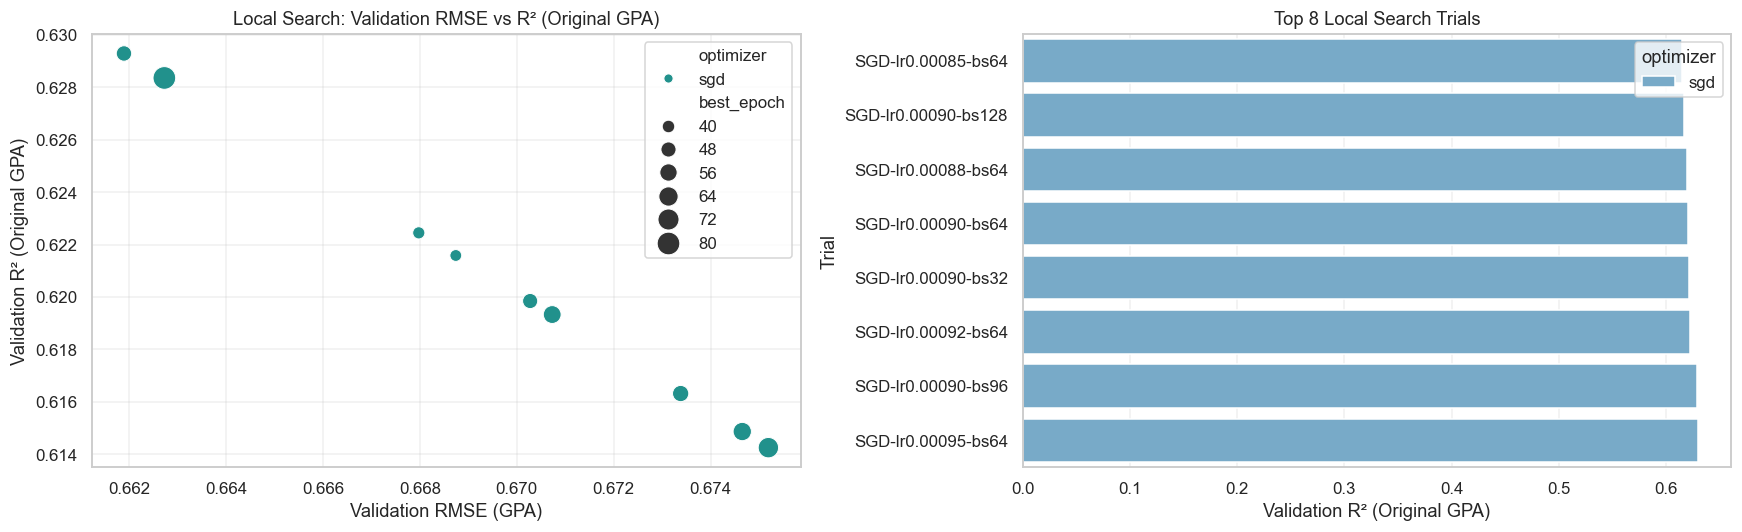

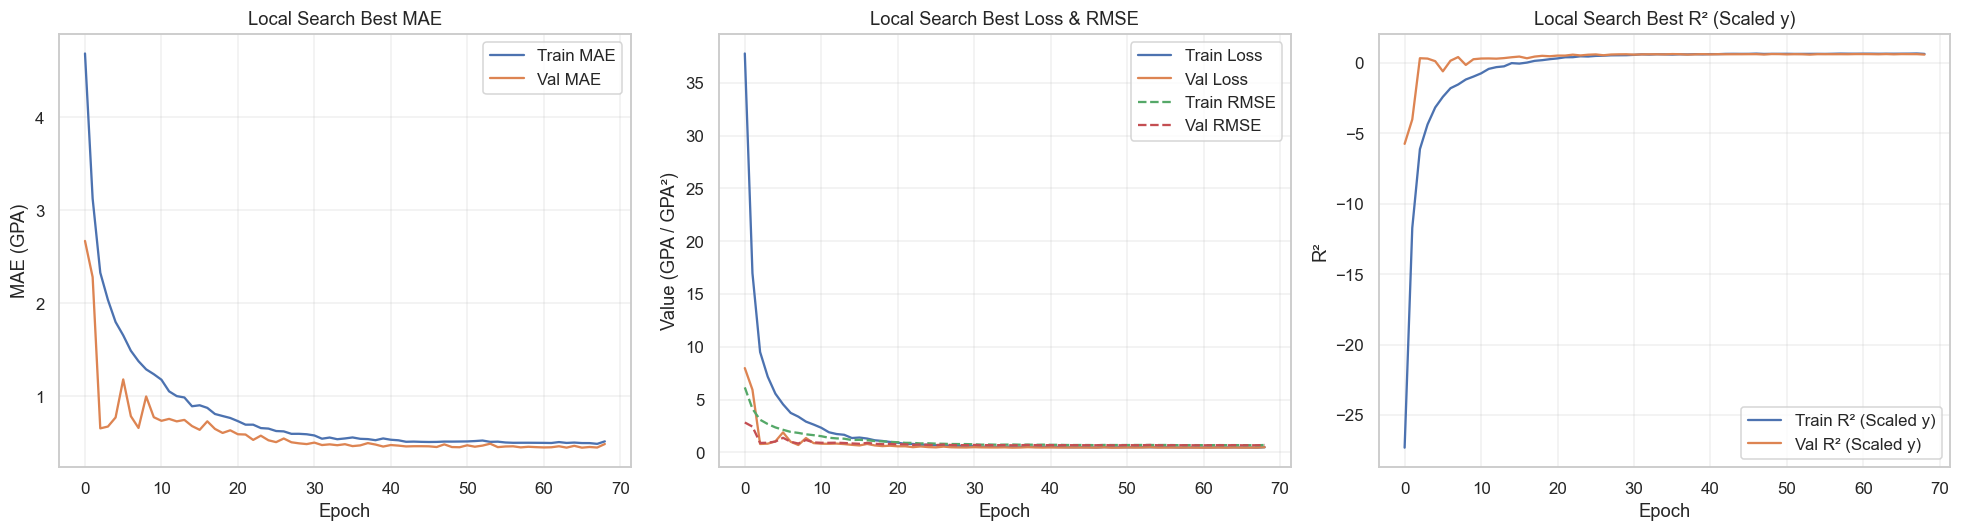


Best Epoch: 49
----------------------------------------
MAE (GPA)   -> Train: 0.5143 | Val: 0.4559
RMSE (GPA)  -> Train: 0.6877 | Val: 0.6619
Loss (GPA²) -> Train: 0.4729 | Val: 0.4381
R² (Scaled y) -> Train: 0.6454 | Val: 0.6293


In [ ]:
plot_local_search_summary(local_search_results_df)
plot_regression_history(best_local_history, title_prefix='Local Search Best')

In [ ]:
local_val_metrics, local_val_df = evaluate_model_original_scale(
    best_local_model, X_val, y_val, scaler, split_name='Local Search Validation'
)
local_test_metrics, local_test_df = evaluate_model_original_scale(
    best_local_model, X_test, y_test, scaler, split_name='Local Search Test'
)

local_summary_df = pd.DataFrame([local_val_metrics, local_test_metrics]).set_index('split')
display(format_metrics_display(local_summary_df))
display(local_test_df.head(15))

Local Search Validation RMSE: 0.6619
Local Search Validation MSE:  0.4381
Local Search Validation MAE:              0.4559
Local Search Validation R² (Original GPA): 0.6293
Local Search Validation R² (Scaled y):     0.6293
Local Search Test RMSE: 0.5744
Local Search Test MSE:  0.3299
Local Search Test MAE:              0.4325
Local Search Test R² (Original GPA): 0.7009
Local Search Test R² (Scaled y):     0.7009


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Local Search Validation,0.661893,0.438103,0.45588,0.629291,0.629291
Local Search Test,0.574405,0.329941,0.43251,0.700933,0.700933


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,3.000000,0.966024,2.033976,2.033976,4.137059
1,2.978261,1.256361,1.721900,1.721900,2.964941
2,0.000000,1.721816,-1.721816,1.721816,2.964652
3,0.250000,1.925565,-1.675565,1.675565,2.807519
4,0.000000,1.675318,-1.675318,1.675318,2.806689
5,0.000000,1.595606,-1.595606,1.595606,2.545959
6,0.000000,1.458810,-1.458810,1.458810,2.128126
7,3.222222,1.839720,1.382502,1.382502,1.911311
8,1.619048,2.996489,-1.377441,1.377441,1.897344
9,3.375000,2.000887,1.374113,1.374113,1.888187


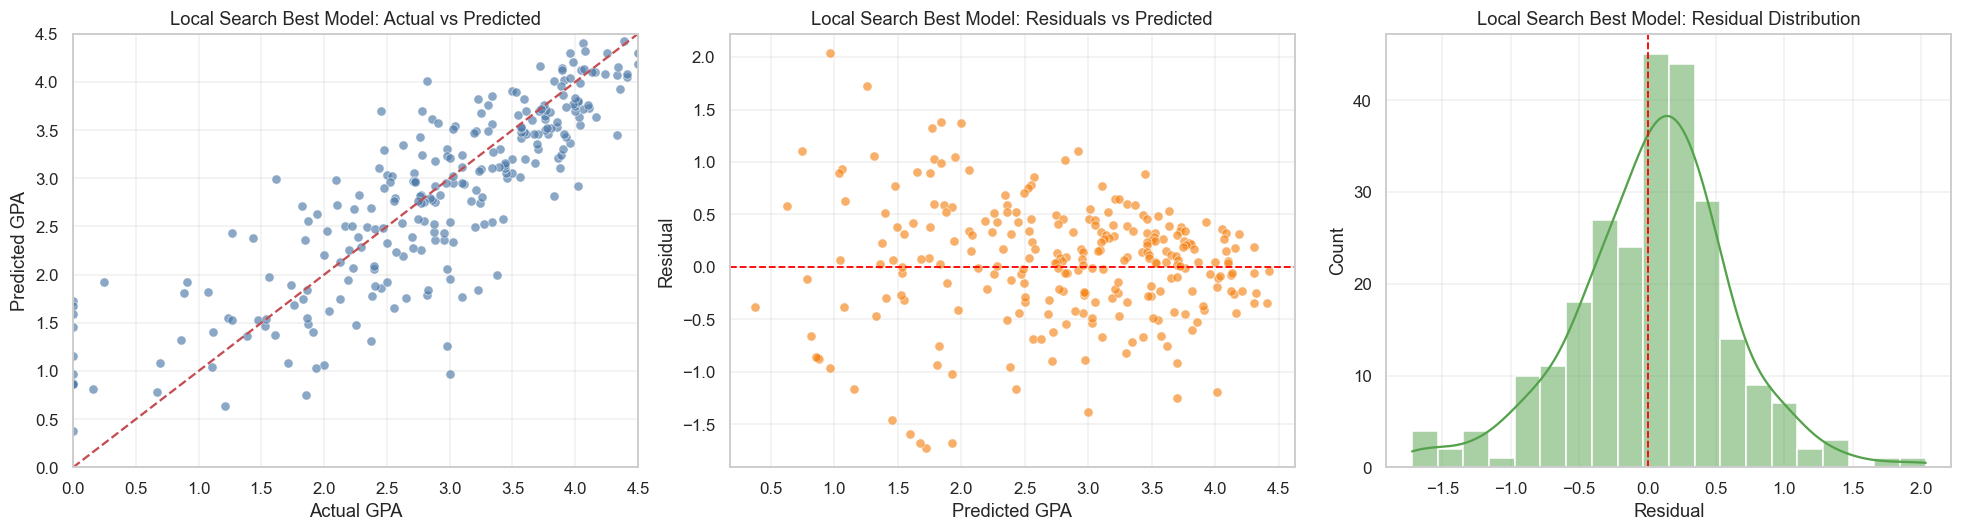

In [ ]:
plot_prediction_diagnostics(local_test_df, title_prefix='Local Search Best Model')

### Model Comparison and Grouped Feature Importance

,Model,Split,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
0,Baseline,Validation,0.729210,0.531748,0.508541,0.550052,0.550052
1,Baseline,Test,0.646360,0.417782,0.505214,0.621313,0.621313
2,Hyperband Best,Validation,0.688860,0.474528,0.500941,0.598469,0.598469
3,Hyperband Best,Test,0.629382,0.396122,0.477172,0.640946,0.640946
4,Custom,Validation,0.664734,0.441871,0.446367,0.626103,0.626103
5,Custom,Test,0.569572,0.324412,0.432889,0.705945,0.705945
6,Local Search,Validation,0.661893,0.438103,0.455880,0.629291,0.629291
7,Local Search,Test,0.574405,0.329941,0.432510,0.700933,0.700933


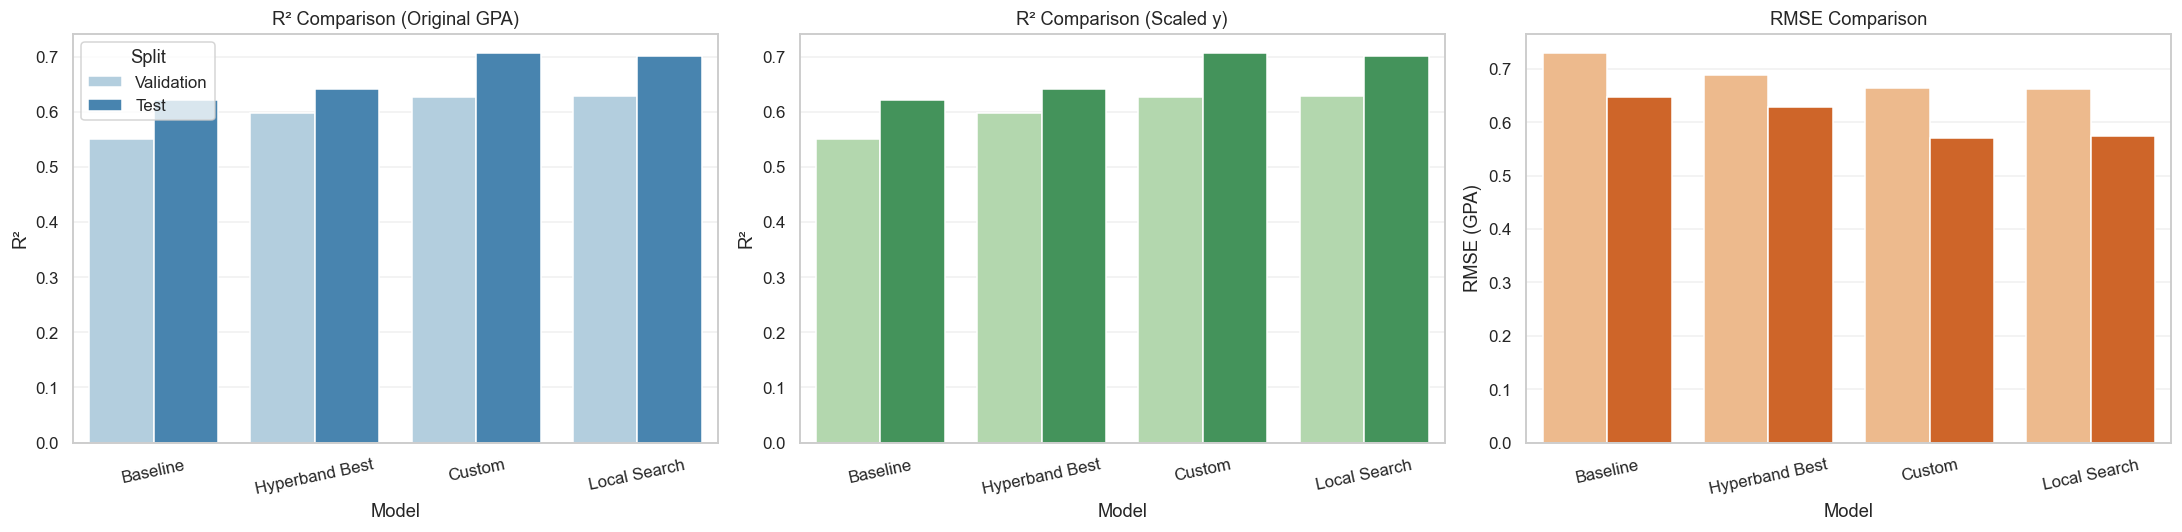

,Model,Split,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
0,Custom,Test,0.569572,0.324412,0.432889,0.705945,0.705945
1,Local Search,Test,0.574405,0.329941,0.432510,0.700933,0.700933
2,Hyperband Best,Test,0.629382,0.396122,0.477172,0.640946,0.640946
3,Baseline,Test,0.646360,0.417782,0.505214,0.621313,0.621313


In [ ]:
experiment_models = {
    'Baseline': baseline_model,
    'Hyperband Best': best_model,
    'Custom': custom_model,
    'Local Search': best_local_model,
}

comparison_df = pd.DataFrame([
    {'Model': 'Baseline', 'Split': 'Validation', **{k: v for k, v in baseline_val_metrics.items() if k != 'split'}},
    {'Model': 'Baseline', 'Split': 'Test', **{k: v for k, v in baseline_test_metrics.items() if k != 'split'}},
    {'Model': 'Hyperband Best', 'Split': 'Validation', **{k: v for k, v in best_val_metrics.items() if k != 'split'}},
    {'Model': 'Hyperband Best', 'Split': 'Test', **{k: v for k, v in best_test_metrics.items() if k != 'split'}},
    {'Model': 'Custom', 'Split': 'Validation', **{k: v for k, v in custom_val_metrics.items() if k != 'split'}},
    {'Model': 'Custom', 'Split': 'Test', **{k: v for k, v in custom_test_metrics.items() if k != 'split'}},
    {'Model': 'Local Search', 'Split': 'Validation', **{k: v for k, v in local_val_metrics.items() if k != 'split'}},
    {'Model': 'Local Search', 'Split': 'Test', **{k: v for k, v in local_test_metrics.items() if k != 'split'}},
])

display(format_metrics_display(comparison_df))
plot_experiment_comparison(comparison_df)

validation_rank_df = comparison_df[comparison_df['Split'] == 'Test'].sort_values(['r2_original', 'rmse'], ascending=[False, True]).reset_index(drop=True)
display(format_metrics_display(validation_rank_df))

Selected model for grouped feature importance: Custom


,Feature Group,RMSE Increase (Mean),RMSE Increase (Std),R² Drop (Mean),Grouped Columns
0,first_term_gpa,0.187470,0.011885,0.225556,"first_term_gpa, first_term_gpa_sq"
1,preparedness_gap,0.053425,0.004418,0.057769,preparedness_gap
2,first_term_gpa_sq,0.045284,0.009509,0.048699,first_term_gpa_sq
3,gpa_hs_interaction,0.039673,0.003770,0.042404,gpa_hs_interaction
4,high_school_average_mark,0.030625,0.002038,0.032475,high_school_average_mark
5,age_group,0.020100,0.004755,0.021141,age_group
6,gpa_english_interaction,0.016125,0.003142,0.016894,gpa_english_interaction
7,hs_math_interaction,0.005154,0.000729,0.005346,hs_math_interaction
8,gender,0.004475,0.001943,0.004643,"gender_1, gender_2"
9,hs_math_gap,0.004197,0.000314,0.004350,hs_math_gap


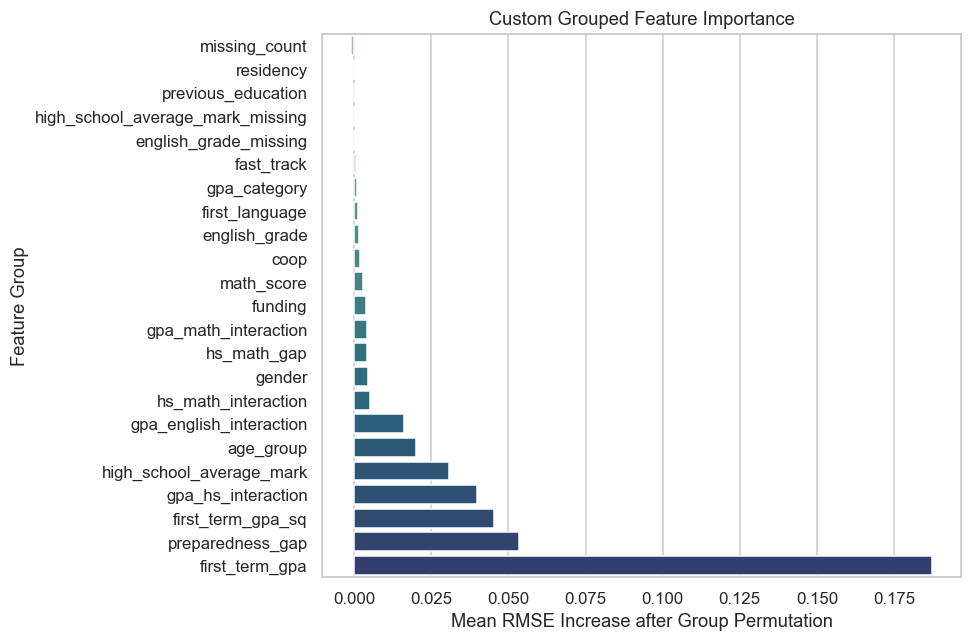

In [ ]:
selected_model_name = validation_rank_df.iloc[0]['Model']
selected_model = experiment_models[selected_model_name]
print(f'Selected model for grouped feature importance: {selected_model_name}')

grouped_importance_df = compute_grouped_permutation_importance(
    selected_model,
    X_test,
    y_test,
    scaler,
    n_repeats=3,
    random_state=42,
)

display(grouped_importance_df)
plot_grouped_feature_importance(
    grouped_importance_df,
    title=f'{selected_model_name} Grouped Feature Importance',
)